In [2]:
# ==========================================================
# CELDA 0 — Split train/val por host (IDS2018) · v2.3 depurada
# ==========================================================
import os, gc, re
from pathlib import Path
import numpy as np, pandas as pd
from sklearn.model_selection import StratifiedShuffleSplit

SEED = 42
np.random.seed(SEED)

# ---- Montar Drive (Colab) ----
try:
    from google.colab import drive
    if not os.path.ismount("/content/drive"):
        drive.mount('/content/drive')
except Exception:
    pass

# ---- Detectar BASE ----
CANDIDATE_BASES = [
    Path("/content/drive/MyDrive/TFG/datasets/IDS2018"),
    Path("/content/drive/MyDrive/datasets/IDS2018"),
    Path("/content/drive_cic/MyDrive/TFG/datasets/IDS2018"),
    Path("/content/drive_cic/MyDrive/datasets/IDS2018"),
]
BASE = next((b for b in CANDIDATE_BASES if b.exists()), None)
if BASE is None:
    target = "Wednesday-14-02-2018_TrafficForML_CICFlowMeter.csv"
    found = list(Path("/content/drive").rglob(target))
    if found:
        BASE = found[0].parent
assert BASE is not None, "No encuentro IDS2018 en tu Drive."
print("📁 BASE:", BASE)

RAW_FILES = [
    BASE / "Wednesday-14-02-2018_TrafficForML_CICFlowMeter.csv",
    BASE / "Thursday-15-02-2018_TrafficForML_CICFlowMeter.csv",
    BASE / "Friday-16-02-2018_TrafficForML_CICFlowMeter.csv",
]
for f in RAW_FILES:
    assert f.exists(), f"Falta: {f.name}"
print("📄 Ficheros:", [p.name for p in RAW_FILES])

# ---- Salidas ----
OUT = BASE / "prepared"
OUT.mkdir(parents=True, exist_ok=True)
TRAIN_CSV = OUT / "train_full.csv"
VAL_CSV   = OUT / "val_full.csv"
for f in (TRAIN_CSV, VAL_CSV):
    if f.exists():
        f.unlink()

# ---- Config ----
CHUNK = 200_000
IP_REGEX = r'(\d{1,3}(?:\.\d{1,3}){3})'

# ---- Utilidades ----
def norm_key(s: str) -> str:
    s = str(s).strip().lower()
    return re.sub(r'[^a-z0-9]', '', s)

def header_map(csv_path: Path):
    df0 = pd.read_csv(csv_path, nrows=0)
    orig = list(df0.columns)
    low2orig = {norm_key(c): c for c in orig}
    return orig, low2orig

def find_col(low2orig, must_all=None, any_of=None):
    keys = list(low2orig.keys())
    if must_all:
        must_all = [norm_key(m) for m in must_all]
        for k in keys:
            if all(m in k for m in must_all):
                return low2orig[k]
    if any_of:
        any_of = [norm_key(a) for a in any_of]
        for k in keys:              # exactos
            if any(a == k for a in any_of):
                return low2orig[k]
        for k in keys:              # contiene
            if any(a in k for a in any_of):
                return low2orig[k]
    return None

def labels_to01(s):
    s = pd.Series(s, dtype=str).str.strip().str.lower()
    return np.where((s=="benign")|(s=="normal"), 0, 1).astype(np.int8)

def first_ip(series):
    s = pd.Series(series, dtype=str)
    return s.str.extract(IP_REGEX, expand=False)

def choose_host_columns(low2orig):
    col_src = find_col(low2orig, any_of=[
        "src ip","source ip","src_ip","source_ip","src addr","source addr",
        "srcaddress","srcaddr","source address"
    ])
    col_dst = find_col(low2orig, any_of=[
        "dst ip","destination ip","dst_ip","destination_ip","dst addr",
        "destination addr","dstaddress","dstaddr","destination address"
    ])
    col_flow = find_col(low2orig, must_all=["flow","id"])
    return col_src, col_dst, col_flow

def get_host_series(chunk, col_src, col_dst, col_flow):
    if col_src is not None and col_src in chunk.columns:
        ip = first_ip(chunk[col_src]);
        if ip.notna().any(): return ip
    if col_dst is not None and col_dst in chunk.columns:
        ip = first_ip(chunk[col_dst]);
        if ip.notna().any(): return ip
    if col_flow is not None and col_flow in chunk.columns:
        ip = first_ip(chunk[col_flow]);
        if ip.notna().any(): return ip
    # último recurso: columnas con 'ip/addr/address'
    for c in chunk.columns:
        nk = norm_key(c)
        if ("ip" in nk) or ("addr" in nk) or ("address" in nk):
            ip = first_ip(chunk[c])
            if ip.notna().any(): return ip
    return pd.Series([None]*len(chunk))

# ---- PASO 1: contar por host (stream) ----
print("🔎 Recuento por host (stream)…")
host_counts = {}
total_rows = 0

for csv_path in RAW_FILES:
    _, low2orig = header_map(csv_path)
    col_label = find_col(low2orig, any_of=["label","class","attack_cat"])
    assert col_label is not None, f"No encuentro columna 'Label' en {csv_path.name}"
    col_src, col_dst, col_flow = choose_host_columns(low2orig)

    usecols = [c for c in [col_label, col_src, col_dst, col_flow] if c is not None] or [col_label]

    for chunk in pd.read_csv(csv_path, usecols=usecols, chunksize=CHUNK, dtype=str, engine="c"):
        total_rows += len(chunk)
        y = labels_to01(chunk[col_label])
        if any([col_src, col_dst, col_flow]):
            host = get_host_series(chunk, col_src, col_dst, col_flow)
            mask = host.notna()
            if mask.any():
                df_aux = pd.DataFrame({"host": host[mask].values, "y": y[mask.values]})
                gb = df_aux.groupby("host")["y"]
                attacks = gb.sum(); totals = gb.count(); benigns = totals - attacks
                for h in attacks.index:
                    b = int(benigns.loc[h]); a = int(attacks.loc[h])
                    if h in host_counts:
                        host_counts[h][0] += b; host_counts[h][1] += a
                    else:
                        host_counts[h] = [b, a]
    gc.collect()

print(f"✅ Hosts: {len(host_counts)} | filas: {total_rows:,}")

# ---- Estratificar hosts (B/M/A por % ataque) ----
hosts = np.array(list(host_counts.keys()))
counts = np.array(list(host_counts.values()), dtype=np.int64) if host_counts else np.zeros((0,2), dtype=np.int64)
if len(hosts) > 0:
    benign, attack = counts[:,0], counts[:,1]
    totals = benign + attack
    frac_attack = np.divide(attack, np.maximum(totals,1), where=totals>0)
    cats = np.full_like(frac_attack, "M", dtype=object)
    cats[frac_attack <= 0.2] = "B"; cats[frac_attack >= 0.8] = "A"
    sss = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=SEED)
    idx_tr, idx_va = next(sss.split(hosts.reshape(-1,1), cats))
    TRAIN_HOSTS, VAL_HOSTS = set(hosts[idx_tr]), set(hosts[idx_va])
else:
    TRAIN_HOSTS, VAL_HOSTS = set(), set()
print(f"📑 Hosts → train:{len(TRAIN_HOSTS)} | val:{len(VAL_HOSTS)}")

# ---- PASO 2: volcado por chunks (con cabeceras independientes) ----
print("💾 Escribiendo train_full.csv y val_full.csv…")
header_written_train = False
header_written_val   = False
n_train = n_val = 0

for csv_path in RAW_FILES:
    _, low2orig = header_map(csv_path)
    col_label = find_col(low2orig, any_of=["label","class","attack_cat"])
    col_src, col_dst, col_flow = choose_host_columns(low2orig)

    for chunk in pd.read_csv(csv_path, chunksize=CHUNK, engine="c"):
        # serie de host (puede no existir en algunos ficheros)
        host = get_host_series(chunk, col_src, col_dst, col_flow)

        if host.isna().all():
            # fallback: split estratificado por filas usando y
            y = labels_to01(chunk[col_label])
            sss = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=SEED)
            idx_tr, idx_va = next(sss.split(np.zeros((len(y),1)), y))
            mask_tr = pd.Series(False, index=chunk.index); mask_tr.iloc[idx_tr] = True
            mask_va = ~mask_tr
        else:
            is_train = host.isin(TRAIN_HOSTS)
            is_val   = host.isin(VAL_HOSTS)
            unknown  = ~(is_train | is_val)
            mask_tr = is_train | unknown   # desconocidos → train
            mask_va = is_val

        tr_part = chunk.loc[mask_tr]
        va_part = chunk.loc[mask_va]

        if len(tr_part):
            tr_part.to_csv(
                TRAIN_CSV, index=False, mode="a",
                header=(not header_written_train)
            )
            n_train += len(tr_part)
            header_written_train = True

        if len(va_part):
            va_part.to_csv(
                VAL_CSV, index=False, mode="a",
                header=(not header_written_val)
            )
            n_val += len(va_part)
            header_written_val = True

    gc.collect()

print(f"✅ Terminado. Filas → train: {n_train:,} | val: {n_val:,}")
print("Archivos:")
print(" -", TRAIN_CSV)
print(" -", VAL_CSV)


📁 BASE: /content/drive/MyDrive/TFG/DATASETS/IDS2018
📄 Ficheros: ['Wednesday-14-02-2018_TrafficForML_CICFlowMeter.csv', 'Thursday-15-02-2018_TrafficForML_CICFlowMeter.csv', 'Friday-16-02-2018_TrafficForML_CICFlowMeter.csv']
🔎 Recuento por host (stream)…
✅ Hosts: 0 | filas: 3,145,725
📑 Hosts → train:0 | val:0
💾 Escribiendo train_full.csv y val_full.csv…


/tmp/ipython-input-2173799307.py:184: DtypeWarning: Columns (0,1,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78) have mixed types. Specify dtype option on import or set low_memory=False.
  for chunk in pd.read_csv(csv_path, chunksize=CHUNK, engine="c"):


✅ Terminado. Filas → train: 2,516,580 | val: 629,145
Archivos:
 - /content/drive/MyDrive/TFG/DATASETS/IDS2018/prepared/train_full.csv
 - /content/drive/MyDrive/TFG/DATASETS/IDS2018/prepared/val_full.csv


In [ ]:
# ============================================
# CELDA 0.5 — ¿Cuántas columnas tiene IDS2018?
# ============================================
from pathlib import Path
import pandas as pd

def ncols(path: Path) -> int:
    return len(pd.read_csv(path, nrows=0).columns)

def header(path: Path):
    return list(pd.read_csv(path, nrows=0).columns)

print("RAW (CSV originales):")
raw_headers = []
for p in RAW_FILES:
    c = ncols(p)
    print(f" - {p.name}: {c} columnas")
    raw_headers.append((p.name, header(p)))

# ¿coinciden los encabezados entre días?
same = all(raw_headers[0][1] == h for _, h in raw_headers[1:])
if not same:
    print("\n⚠️ Los encabezados NO son idénticos entre días.")
    base = set(raw_headers[0][1])
    for name, h in raw_headers[1:]:
        extra = set(h) - base
        miss  = base - set(h)
        if extra:
            print(f"   · {name} tiene columnas extra: {sorted(list(extra))[:8]}{' …' if len(extra)>8 else ''}")
        if miss:
            print(f"   · {name} le faltan: {sorted(list(miss))[:8]}{' …' if len(miss)>8 else ''}")
else:
    print("✅ Los encabezados de los 3 días son idénticos.")

# PREPARED (si existen)
for p in [TRAIN_CSV, VAL_CSV]:
    if p.exists():
        print(f"\n{p.name}: {ncols(p)} columnas")


RAW (CSV originales):
 - Wednesday-14-02-2018_TrafficForML_CICFlowMeter.csv: 80 columnas
 - Thursday-15-02-2018_TrafficForML_CICFlowMeter.csv: 80 columnas
 - Friday-16-02-2018_TrafficForML_CICFlowMeter.csv: 80 columnas
✅ Los encabezados de los 3 días son idénticos.

train_full.csv: 80 columnas

val_full.csv: 80 columnas


In [ ]:
# ============================================
# CELDA 0.6 — Ver TODAS las columnas (+ detectar 'timestamp/time')
# ============================================
import re
import pandas as pd
from pathlib import Path

TIME_PATTERNS = [
    r'time', r'timestamp', r'start[_ ]?time', r'end[_ ]?time',
    r'stime', r'etime', r'flow[_ ]?start', r'flow[_ ]?end'
]

def norm(s: str) -> str:
    return re.sub(r'[^a-z0-9]+', ' ', str(s).strip().lower())

def mark_time(col: str) -> bool:
    n = norm(col)
    return any(re.search(p, n) for p in TIME_PATTERNS)

def show_columns(csv_path: Path, max_preview: int = None):
    print(f"\n📄 {csv_path.name}")
    cols = list(pd.read_csv(csv_path, nrows=0).columns)
    print(f"→ {len(cols)} columnas")
    # Mostrar todas (o las primeras max_preview)
    to_show = cols if max_preview is None else cols[:max_preview]
    for i, c in enumerate(to_show, 1):
        tag = "  ⏱️" if mark_time(c) else ""
        print(f"{i:>3}. {c}{tag}")
    if max_preview is not None and len(cols) > max_preview:
        print(f"... ({len(cols) - max_preview} más)")

# ---- RAW: todos los ficheros originales
print("RAW (CSV originales):")
for p in RAW_FILES:
    show_columns(p)

# ---- PREPARED (si existen): train/val completos tras el split
print("\nPREPARED (si existen):")
for p in [TRAIN_CSV, VAL_CSV]:
    if p.exists():
        show_columns(p)
    else:
        print(f"- {p.name} no existe todavía.")

# ---- Resumen: columnas "de tiempo" detectadas por fichero
print("\n⏱️ Resumen de columnas tipo tiempo por fichero:")
for p in RAW_FILES + [TRAIN_CSV, VAL_CSV]:
    if p.exists():
        cols = list(pd.read_csv(p, nrows=0).columns)
        time_like = [c for c in cols if mark_time(c)]
        print(f" - {p.name}: {time_like if time_like else '—'}")

RAW (CSV originales):

📄 Wednesday-14-02-2018_TrafficForML_CICFlowMeter.csv
→ 80 columnas
  1. Dst Port
  2. Protocol
  3. Timestamp  ⏱️
  4. Flow Duration
  5. Tot Fwd Pkts
  6. Tot Bwd Pkts
  7. TotLen Fwd Pkts
  8. TotLen Bwd Pkts
  9. Fwd Pkt Len Max
 10. Fwd Pkt Len Min
 11. Fwd Pkt Len Mean
 12. Fwd Pkt Len Std
 13. Bwd Pkt Len Max
 14. Bwd Pkt Len Min
 15. Bwd Pkt Len Mean
 16. Bwd Pkt Len Std
 17. Flow Byts/s
 18. Flow Pkts/s
 19. Flow IAT Mean
 20. Flow IAT Std
 21. Flow IAT Max
 22. Flow IAT Min
 23. Fwd IAT Tot
 24. Fwd IAT Mean
 25. Fwd IAT Std
 26. Fwd IAT Max
 27. Fwd IAT Min
 28. Bwd IAT Tot
 29. Bwd IAT Mean
 30. Bwd IAT Std
 31. Bwd IAT Max
 32. Bwd IAT Min
 33. Fwd PSH Flags
 34. Bwd PSH Flags
 35. Fwd URG Flags
 36. Bwd URG Flags
 37. Fwd Header Len
 38. Bwd Header Len
 39. Fwd Pkts/s
 40. Bwd Pkts/s
 41. Pkt Len Min
 42. Pkt Len Max
 43. Pkt Len Mean
 44. Pkt Len Std
 45. Pkt Len Var
 46. FIN Flag Cnt
 47. SYN Flag Cnt
 48. RST Flag Cnt
 49. PSH Flag Cnt
 50. ACK Fl

In [ ]:
# ============================================
# CELDA 0.7 — Vista de 10 filas (todas las columnas y valores)
# ============================================
import pandas as pd
from pathlib import Path

# Ajustes de impresión para ver todas las columnas en el notebook
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 2000)
pd.set_option("display.max_colwidth", 200)

N = 10  # nº de filas a mostrar

def preview_head(csv_path: Path, n: int = 10):
    print(f"\n📄 {csv_path.name} — primeras {n} filas")
    try:
        df = pd.read_csv(csv_path, nrows=n, low_memory=False)
        display(df)  # en Colab/Jupyter muestra tabla bonita
        # Si prefieres en texto plano, descomenta:
        # print(df.to_string(index=False))
    except Exception as e:
        print("  ⚠️ No se pudo leer:", e)

print("RAW (CSV originales):")
for p in RAW_FILES:
    if p.exists():
        preview_head(p, N)
    else:
        print(f" - {p.name} no existe.")

print("\nPREPARED (tras el split):")
for p in [TRAIN_CSV, VAL_CSV]:
    if p.exists():
        preview_head(p, N)
    else:
        print(f" - {p.name} no existe todavía.")

RAW (CSV originales):

📄 Wednesday-14-02-2018_TrafficForML_CICFlowMeter.csv — primeras 10 filas


,Dst Port,Protocol,Timestamp,Flow Duration,Tot Fwd Pkts,Tot Bwd Pkts,TotLen Fwd Pkts,TotLen Bwd Pkts,Fwd Pkt Len Max,Fwd Pkt Len Min,Fwd Pkt Len Mean,Fwd Pkt Len Std,Bwd Pkt Len Max,Bwd Pkt Len Min,Bwd Pkt Len Mean,Bwd Pkt Len Std,Flow Byts/s,Flow Pkts/s,Flow IAT Mean,Flow IAT Std,Flow IAT Max,Flow IAT Min,Fwd IAT Tot,Fwd IAT Mean,Fwd IAT Std,Fwd IAT Max,Fwd IAT Min,Bwd IAT Tot,Bwd IAT Mean,Bwd IAT Std,Bwd IAT Max,Bwd IAT Min,Fwd PSH Flags,Bwd PSH Flags,Fwd URG Flags,Bwd URG Flags,Fwd Header Len,Bwd Header Len,Fwd Pkts/s,Bwd Pkts/s,Pkt Len Min,Pkt Len Max,Pkt Len Mean,Pkt Len Std,Pkt Len Var,FIN Flag Cnt,SYN Flag Cnt,RST Flag Cnt,PSH Flag Cnt,ACK Flag Cnt,URG Flag Cnt,CWE Flag Count,ECE Flag Cnt,Down/Up Ratio,Pkt Size Avg,Fwd Seg Size Avg,Bwd Seg Size Avg,Fwd Byts/b Avg,Fwd Pkts/b Avg,Fwd Blk Rate Avg,Bwd Byts/b Avg,Bwd Pkts/b Avg,Bwd Blk Rate Avg,Subflow Fwd Pkts,Subflow Fwd Byts,Subflow Bwd Pkts,Subflow Bwd Byts,Init Fwd Win Byts,Init Bwd Win Byts,Fwd Act Data Pkts,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,0,0,14/02/2018 08:31:01,112641719,3,0,0,0,0,0,0.000000,0.000000,0,0,0.000000,0.000000,0.000000,0.026633,5.632086e+07,139.300036,56320958,56320761,112641719,5.632086e+07,139.300036,56320958,56320761,0,0.000000,0.000000,0,0,0,0,0,0,0,0,0.026633,0.000000,0,0,0.000000,0.000000,0.000000,0,0,0,0,0,0,0,0,0,0.000000,0.000000,0.000000,0,0,0,0,0,0,3,0,0,0,-1,-1,0,0,0,0,0,0,56320859.5,139.300036,56320958,56320761,Benign
1,0,0,14/02/2018 08:33:50,112641466,3,0,0,0,0,0,0.000000,0.000000,0,0,0.000000,0.000000,0.000000,0.026633,5.632073e+07,114.551299,56320814,56320652,112641466,5.632073e+07,114.551299,56320814,56320652,0,0.000000,0.000000,0,0,0,0,0,0,0,0,0.026633,0.000000,0,0,0.000000,0.000000,0.000000,0,0,0,0,0,0,0,0,0,0.000000,0.000000,0.000000,0,0,0,0,0,0,3,0,0,0,-1,-1,0,0,0,0,0,0,56320733.0,114.551299,56320814,56320652,Benign
2,0,0,14/02/2018 08:36:39,112638623,3,0,0,0,0,0,0.000000,0.000000,0,0,0.000000,0.000000,0.000000,0.026634,5.631931e+07,301.934596,56319525,56319098,112638623,5.631931e+07,301.934596,56319525,56319098,0,0.000000,0.000000,0,0,0,0,0,0,0,0,0.026634,0.000000,0,0,0.000000,0.000000,0.000000,0,0,0,0,0,0,0,0,0,0.000000,0.000000,0.000000,0,0,0,0,0,0,3,0,0,0,-1,-1,0,0,0,0,0,0,56319311.5,301.934596,56319525,56319098,Benign
3,22,6,14/02/2018 08:40:13,6453966,15,10,1239,2273,744,0,82.600000,196.741237,976,0,227.300000,371.677892,544.161528,3.873587,2.689152e+05,247443.778966,673900,22,6453966,4.609976e+05,123109.423588,673900,229740,5637902,626433.555556,455082.214224,1167293,554,0,0,0,0,488,328,2.324152,1.549435,0,976,135.076923,277.834760,77192.153846,0,0,0,1,0,0,0,0,0,140.480000,82.600000,227.300000,0,0,0,0,0,0,15,1239,10,2273,65535,233,6,32,0,0,0,0,0.0,0.000000,0,0,Benign
4,22,6,14/02/2018 08:40:23,8804066,14,11,1143,2209,744,0,81.642857,203.745545,976,0,200.818182,362.249864,380.733175,2.839597,3.668361e+05,511356.609733,1928102,21,8804066,6.772358e+05,532416.970959,1928102,246924,7715481,771548.100000,755543.082717,2174893,90,0,0,0,0,456,360,1.590174,1.249423,0,976,128.923077,279.763032,78267.353846,0,0,0,1,0,0,0,0,0,134.080000,81.642857,200.818182,0,0,0,0,0,0,14,1143,11,2209,5808,233,6,32,0,0,0,0,0.0,0.000000,0,0,Benign
5,22,6,14/02/2018 08:40:31,6989341,16,12,1239,2273,744,0,77.437500,190.831154,976,0,189.416667,347.642569,502.479418,4.006100,2.588645e+05,291724.147911,951098,20,6989341,4.659561e+05,244363.896416,951098,265831,5980598,543690.727273,460713.519752,1254338,78,0,0,0,0,332,252,2.289200,1.716900,0,976,121.103448,265.708668,70601.096059,0,0,0,1,0,0,0,0,0,125.428571,77.437500,189.416667,0,0,0,0,0,0,16,1239,12,2273,5808,234,7,20,0,0,0,0,0.0,0.000000,0,0,Benign
6,0,0,14/02/2018 08:39:28,112640480,3,0,0,0,0,0,0.000000,0.000000,0,0,0.000000,0.000000,0.000000,0.026633,5.632024e+07,203.646753,56320384,56320096,112640480,5.632024e+07,203.646753,56320384,56320096,0,0.000000,0.000000,0,0,0,0,0,0,0,0,0.026633,0.000000,0,0,0.000000,0.000000,0.000000,0,0,0


📄 Thursday-15-02-2018_TrafficForML_CICFlowMeter.csv — primeras 10 filas


,Dst Port,Protocol,Timestamp,Flow Duration,Tot Fwd Pkts,Tot Bwd Pkts,TotLen Fwd Pkts,TotLen Bwd Pkts,Fwd Pkt Len Max,Fwd Pkt Len Min,Fwd Pkt Len Mean,Fwd Pkt Len Std,Bwd Pkt Len Max,Bwd Pkt Len Min,Bwd Pkt Len Mean,Bwd Pkt Len Std,Flow Byts/s,Flow Pkts/s,Flow IAT Mean,Flow IAT Std,Flow IAT Max,Flow IAT Min,Fwd IAT Tot,Fwd IAT Mean,Fwd IAT Std,Fwd IAT Max,Fwd IAT Min,Bwd IAT Tot,Bwd IAT Mean,Bwd IAT Std,Bwd IAT Max,Bwd IAT Min,Fwd PSH Flags,Bwd PSH Flags,Fwd URG Flags,Bwd URG Flags,Fwd Header Len,Bwd Header Len,Fwd Pkts/s,Bwd Pkts/s,Pkt Len Min,Pkt Len Max,Pkt Len Mean,Pkt Len Std,Pkt Len Var,FIN Flag Cnt,SYN Flag Cnt,RST Flag Cnt,PSH Flag Cnt,ACK Flag Cnt,URG Flag Cnt,CWE Flag Count,ECE Flag Cnt,Down/Up Ratio,Pkt Size Avg,Fwd Seg Size Avg,Bwd Seg Size Avg,Fwd Byts/b Avg,Fwd Pkts/b Avg,Fwd Blk Rate Avg,Bwd Byts/b Avg,Bwd Pkts/b Avg,Bwd Blk Rate Avg,Subflow Fwd Pkts,Subflow Fwd Byts,Subflow Bwd Pkts,Subflow Bwd Byts,Init Fwd Win Byts,Init Bwd Win Byts,Fwd Act Data Pkts,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,0,0,15/02/2018 08:25:18,112641158,3,0,0,0,0,0,0.000000,0.000000,0,0,0.000000,0.000000,0.000000,0.026633,5.632058e+07,7.042784e+02,56321077,56320081,112641158,5.632058e+07,7.042784e+02,56321077,56320081,0,0.000000e+00,0.000000e+00,0,0,0,0,0,0,0,0,0.026633,0.000000,0,0,0.000000,0.000000,0.000000,0,0,0,0,0,0,0,0,0,0.000000,0.000000,0.000000,0,0,0,0,0,0,3,0,0,0,-1,-1,0,0,0,0.000000,0,0,56320579.0,7.042784e+02,56321077,56320081,Benign
1,22,6,15/02/2018 08:29:05,37366762,14,12,2168,2993,712,0,154.857143,254.855270,976,0,249.416667,395.929392,138.117400,0.695806,1.494670e+06,3.894924e+06,15617415,7,37366762,2.874366e+06,5.104444e+06,15617415,40,37366730,3.396975e+06,5.564224e+06,15936762,893,0,0,0,0,456,416,0.374665,0.321141,0,976,191.148148,320.122898,102478.669516,0,0,0,1,0,0,0,0,0,198.500000,154.857143,249.416667,0,0,0,0,0,0,14,2168,12,2993,29200,232,8,32,1024353,649038.754495,1601183,321569,11431221.0,3.644991e+06,15617415,8960247,Benign
2,47514,6,15/02/2018 08:29:42,543,2,0,64,0,64,0,32.000000,45.254834,0,0,0.000000,0.000000,117863.720074,3683.241252,5.430000e+02,0.000000e+00,543,543,543,5.430000e+02,0.000000e+00,543,543,0,0.000000e+00,0.000000e+00,0,0,1,0,0,0,64,0,3683.241252,0.000000,0,64,42.666667,36.950417,1365.333333,0,1,0,0,1,0,0,0,0,64.000000,32.000000,0.000000,0,0,0,0,0,0,2,64,0,0,244,-1,0,32,0,0.000000,0,0,0.0,0.000000e+00,0,0,Benign
3,0,0,15/02/2018 08:28:07,112640703,3,0,0,0,0,0,0.000000,0.000000,0,0,0.000000,0.000000,0.000000,0.026633,5.632035e+07,3.669884e+02,56320611,56320092,112640703,5.632035e+07,3.669884e+02,56320611,56320092,0,0.000000e+00,0.000000e+00,0,0,0,0,0,0,0,0,0.026633,0.000000,0,0,0.000000,0.000000,0.000000,0,0,0,0,0,0,0,0,0,0.000000,0.000000,0.000000,0,0,0,0,0,0,3,0,0,0,-1,-1,0,0,0,0.000000,0,0,56320351.5,3.669884e+02,56320611,56320092,Benign
4,0,0,15/02/2018 08:30:56,112640874,3,0,0,0,0,0,0.000000,0.000000,0,0,0.000000,0.000000,0.000000,0.026633,5.632044e+07,7.198347e+02,56320946,56319928,112640874,5.632044e+07,7.198347e+02,56320946,56319928,0,0.000000e+00,0.000000e+00,0,0,0,0,0,0,0,0,0.026633,0.000000,0,0,0.000000,0.000000,0.000000,0,0,0,0,0,0,0,0,0,0.000000,0.000000,0.000000,0,0,0,0,0,0,3,0,0,0,-1,-1,0,0,0,0.000000,0,0,56320437.0,7.198347e+02,56320946,56319928,Benign
5,0,0,15/02/2018 08:33:45,112640945,3,0,0,0,0,0,0.000000,0.000000,0,0,0.000000,0.000000,0.000000,0.026633,5.632047e+07,2.213244e+02,56320629,56320316,112640945,5.632047e+07,2.213244e+02,56320629,56320316,0,0.000000e+00,0.000000e+00,0,0,0,0,0,0,0,0,0.026633,0.000000,0,0,0.000000,0.000000,0.000000,0,0,0,0,0,0,0,0,0,0.000000,0.000000,0.000000,0,0,0,0,0,0,3,0,0,0,-1,-1,0,0,0,0.000000,0,0,56320472.5,2.213244e+02,56320629,56320316,Benign
6,80,6,15/02/2018 08:37:04,179213,3,4,182,935,182,0,60.666667,105.077749,935,0,233.750000,467.500000,6232.806772,39.059666,2.986883e+04,7.215331e+04,177147,23,177282,8.864100e+04,1.252003e+05,177171,111,179189,5.972967e+04,1.018036e+05,1772


📄 Friday-16-02-2018_TrafficForML_CICFlowMeter.csv — primeras 10 filas


,Dst Port,Protocol,Timestamp,Flow Duration,Tot Fwd Pkts,Tot Bwd Pkts,TotLen Fwd Pkts,TotLen Bwd Pkts,Fwd Pkt Len Max,Fwd Pkt Len Min,Fwd Pkt Len Mean,Fwd Pkt Len Std,Bwd Pkt Len Max,Bwd Pkt Len Min,Bwd Pkt Len Mean,Bwd Pkt Len Std,Flow Byts/s,Flow Pkts/s,Flow IAT Mean,Flow IAT Std,Flow IAT Max,Flow IAT Min,Fwd IAT Tot,Fwd IAT Mean,Fwd IAT Std,Fwd IAT Max,Fwd IAT Min,Bwd IAT Tot,Bwd IAT Mean,Bwd IAT Std,Bwd IAT Max,Bwd IAT Min,Fwd PSH Flags,Bwd PSH Flags,Fwd URG Flags,Bwd URG Flags,Fwd Header Len,Bwd Header Len,Fwd Pkts/s,Bwd Pkts/s,Pkt Len Min,Pkt Len Max,Pkt Len Mean,Pkt Len Std,Pkt Len Var,FIN Flag Cnt,SYN Flag Cnt,RST Flag Cnt,PSH Flag Cnt,ACK Flag Cnt,URG Flag Cnt,CWE Flag Count,ECE Flag Cnt,Down/Up Ratio,Pkt Size Avg,Fwd Seg Size Avg,Bwd Seg Size Avg,Fwd Byts/b Avg,Fwd Pkts/b Avg,Fwd Blk Rate Avg,Bwd Byts/b Avg,Bwd Pkts/b Avg,Bwd Blk Rate Avg,Subflow Fwd Pkts,Subflow Fwd Byts,Subflow Bwd Pkts,Subflow Bwd Byts,Init Fwd Win Byts,Init Bwd Win Byts,Fwd Act Data Pkts,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,0,0,16/02/2018 08:27:23,112640768,3,0,0,0,0,0,0.000000,0.000000,0,0,0.000000,0.000000,0.000000,0.026633,5.630000e+07,1.385929e+02,56300000,56300000,113000000,5.630000e+07,1.385929e+02,56300000,56300000,0,0.0000,0.000,0,0,0,0,0,0,0,0,0.026633,0.000000,0,0,0.000000,0.000000,0.000000,0,0,0,0,0,0,0,0,0,0.000000,0.000000,0.000000,0,0,0,0,0,0,3,0,0,0,-1,-1,0,0,0,0,0,0,56300000,138.592929,56300000,56300000,Benign
1,0,0,16/02/2018 08:30:12,112641773,3,0,0,0,0,0,0.000000,0.000000,0,0,0.000000,0.000000,0.000000,0.026633,5.630000e+07,2.637508e+02,56300000,56300000,113000000,5.630000e+07,2.637508e+02,56300000,56300000,0,0.0000,0.000,0,0,0,0,0,0,0,0,0.026633,0.000000,0,0,0.000000,0.000000,0.000000,0,0,0,0,0,0,0,0,0,0.000000,0.000000,0.000000,0,0,0,0,0,0,3,0,0,0,-1,-1,0,0,0,0,0,0,56300000,263.750829,56300000,56300000,Benign
2,35605,6,16/02/2018 08:26:55,20784143,23,44,2416,1344,240,64,105.043478,54.542292,64,0,30.545455,32.336497,180.907146,3.223611,3.149113e+05,1.145954e+06,9058214,66,20700000,9.404843e+05,1.898330e+06,9144734,66,20700000,482352.2093,1396411.114,9058214,41601,1,0,0,0,460,880,1.106613,2.116999,0,240,56.235294,53.851681,2900.003512,0,1,0,0,1,0,0,0,1,57.074627,105.043478,30.545455,0,0,0,0,0,0,23,2416,44,1344,263,255,22,20,2624734,0,2624734,2624734,9058214,0.000000,9058214,9058214,Benign
3,0,0,16/02/2018 08:33:01,112640836,3,0,0,0,0,0,0.000000,0.000000,0,0,0.000000,0.000000,0.000000,0.026633,5.630000e+07,8.202439e+01,56300000,56300000,113000000,5.630000e+07,8.202439e+01,56300000,56300000,0,0.0000,0.000,0,0,0,0,0,0,0,0,0.026633,0.000000,0,0,0.000000,0.000000,0.000000,0,0,0,0,0,0,0,0,0,0.000000,0.000000,0.000000,0,0,0,0,0,0,3,0,0,0,-1,-1,0,0,0,0,0,0,56300000,82.024387,56300000,56300000,Benign
4,23,6,16/02/2018 08:27:59,20,1,1,0,0,0,0,0.000000,0.000000,0,0,0.000000,0.000000,0.000000,100000.000000,2.000000e+01,0.000000e+00,20,20,0,0.000000e+00,0.000000e+00,0,0,0,0.0000,0.000,0,0,0,0,0,0,20,20,50000.000000,50000.000000,0,0,0.000000,0.000000,0.000000,0,0,0,1,0,0,0,0,1,0.000000,0.000000,0.000000,0,0,0,0,0,0,1,0,1,0,58856,0,0,20,0,0,0,0,0,0.000000,0,0,Benign
5,0,0,16/02/2018 08:35:50,112641178,3,0,0,0,0,0,0.000000,0.000000,0,0,0.000000,0.000000,0.000000,0.026633,5.630000e+07,5.656854e+00,56300000,56300000,113000000,5.630000e+07,5.656854e+00,56300000,56300000,0,0.0000,0.000,0,0,0,0,0,0,0,0,0.026633,0.000000,0,0,0.000000,0.000000,0.000000,0,0,0,0,0,0,0,0,0,0.000000,0.000000,0.000000,0,0,0,0,0,0,3,0,0,0,-1,-1,0,0,0,0,0,0,56300000,5.656854,56300000,56300000,Benign
6,0,0,16/02/2018 08:38:39,112641264,3,0,0,0,0,0,0.000000,0.000000,0,0,0.000000,0.000000,0.000000,0.026633,5.630000e+07,7.071068e+00,56300000,56300000,113000000,5.630000e+07,7.071068e+00,56300000,56300000,0,0.0000,0.000,0,0,0,0,0,0,0,0,0.026633,0.000000,0,0,0.000000,0.000000,0.000000,0,0,0,0,0,0,0,0,0,0.000000,0.000000,0.000000,0,0,0,0,0,0,3,0,0,0,-1,-1,0,0,0,0,0,0,56300000,7.071068,56300000,56300000,Benign
7,0,


PREPARED (tras el split):

📄 train_full.csv — primeras 10 filas


,Dst Port,Protocol,Timestamp,Flow Duration,Tot Fwd Pkts,Tot Bwd Pkts,TotLen Fwd Pkts,TotLen Bwd Pkts,Fwd Pkt Len Max,Fwd Pkt Len Min,Fwd Pkt Len Mean,Fwd Pkt Len Std,Bwd Pkt Len Max,Bwd Pkt Len Min,Bwd Pkt Len Mean,Bwd Pkt Len Std,Flow Byts/s,Flow Pkts/s,Flow IAT Mean,Flow IAT Std,Flow IAT Max,Flow IAT Min,Fwd IAT Tot,Fwd IAT Mean,Fwd IAT Std,Fwd IAT Max,Fwd IAT Min,Bwd IAT Tot,Bwd IAT Mean,Bwd IAT Std,Bwd IAT Max,Bwd IAT Min,Fwd PSH Flags,Bwd PSH Flags,Fwd URG Flags,Bwd URG Flags,Fwd Header Len,Bwd Header Len,Fwd Pkts/s,Bwd Pkts/s,Pkt Len Min,Pkt Len Max,Pkt Len Mean,Pkt Len Std,Pkt Len Var,FIN Flag Cnt,SYN Flag Cnt,RST Flag Cnt,PSH Flag Cnt,ACK Flag Cnt,URG Flag Cnt,CWE Flag Count,ECE Flag Cnt,Down/Up Ratio,Pkt Size Avg,Fwd Seg Size Avg,Bwd Seg Size Avg,Fwd Byts/b Avg,Fwd Pkts/b Avg,Fwd Blk Rate Avg,Bwd Byts/b Avg,Bwd Pkts/b Avg,Bwd Blk Rate Avg,Subflow Fwd Pkts,Subflow Fwd Byts,Subflow Bwd Pkts,Subflow Bwd Byts,Init Fwd Win Byts,Init Bwd Win Byts,Fwd Act Data Pkts,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,0,0,14/02/2018 08:31:01,112641719,3,0,0,0,0,0,0.000000,0.000000,0,0,0.000000,0.000000,0.000000,0.026633,5.632086e+07,139.300036,56320958,56320761,112641719,5.632086e+07,139.300036,56320958,56320761,0,0.000000,0.000000,0,0,0,0,0,0,0,0,0.026633,0.000000,0,0,0.000000,0.000000,0.000000,0,0,0,0,0,0,0,0,0,0.000000,0.000000,0.000000,0,0,0,0,0,0,3,0,0,0,-1,-1,0,0,0.0,0.0,0,0,56320859.5,139.300036,56320958,56320761,Benign
1,0,0,14/02/2018 08:36:39,112638623,3,0,0,0,0,0,0.000000,0.000000,0,0,0.000000,0.000000,0.000000,0.026634,5.631931e+07,301.934596,56319525,56319098,112638623,5.631931e+07,301.934596,56319525,56319098,0,0.000000,0.000000,0,0,0,0,0,0,0,0,0.026634,0.000000,0,0,0.000000,0.000000,0.000000,0,0,0,0,0,0,0,0,0,0.000000,0.000000,0.000000,0,0,0,0,0,0,3,0,0,0,-1,-1,0,0,0.0,0.0,0,0,56319311.5,301.934596,56319525,56319098,Benign
2,22,6,14/02/2018 08:40:13,6453966,15,10,1239,2273,744,0,82.600000,196.741237,976,0,227.300000,371.677892,544.161528,3.873587,2.689152e+05,247443.778966,673900,22,6453966,4.609976e+05,123109.423588,673900,229740,5637902,626433.555556,455082.214224,1167293,554,0,0,0,0,488,328,2.324152,1.549435,0,976,135.076923,277.834760,77192.153846,0,0,0,1,0,0,0,0,0,140.480000,82.600000,227.300000,0,0,0,0,0,0,15,1239,10,2273,65535,233,6,32,0.0,0.0,0,0,0.0,0.000000,0,0,Benign
3,22,6,14/02/2018 08:40:23,8804066,14,11,1143,2209,744,0,81.642857,203.745545,976,0,200.818182,362.249864,380.733175,2.839597,3.668361e+05,511356.609733,1928102,21,8804066,6.772358e+05,532416.970959,1928102,246924,7715481,771548.100000,755543.082717,2174893,90,0,0,0,0,456,360,1.590174,1.249423,0,976,128.923077,279.763032,78267.353846,0,0,0,1,0,0,0,0,0,134.080000,81.642857,200.818182,0,0,0,0,0,0,14,1143,11,2209,5808,233,6,32,0.0,0.0,0,0,0.0,0.000000,0,0,Benign
4,22,6,14/02/2018 08:40:31,6989341,16,12,1239,2273,744,0,77.437500,190.831154,976,0,189.416667,347.642569,502.479418,4.006100,2.588645e+05,291724.147911,951098,20,6989341,4.659561e+05,244363.896416,951098,265831,5980598,543690.727273,460713.519752,1254338,78,0,0,0,0,332,252,2.289200,1.716900,0,976,121.103448,265.708668,70601.096059,0,0,0,1,0,0,0,0,0,125.428571,77.437500,189.416667,0,0,0,0,0,0,16,1239,12,2273,5808,234,7,20,0.0,0.0,0,0,0.0,0.000000,0,0,Benign
5,0,0,14/02/2018 08:39:28,112640480,3,0,0,0,0,0,0.000000,0.000000,0,0,0.000000,0.000000,0.000000,0.026633,5.632024e+07,203.646753,56320384,56320096,112640480,5.632024e+07,203.646753,56320384,56320096,0,0.000000,0.000000,0,0,0,0,0,0,0,0,0.026633,0.000000,0,0,0.000000,0.000000,0.000000,0,0,0,0,0,0,0,0,0,0.000000,0.000000,0.000000,0,0,0,0,0,0,3,0,0,0,-1,-1,0,0,0.0,0.0,0,0,56320240.0,203.646753,56320384,56320096,Benign
6,0,0,14/02/2018 08:42:17,112641244,3,0,0,0,0,0,0.000000,0.000000,0,0,0.000000,0.000000,0.000000,0.026633,5.632062e+07,62.225397,56320666,56320578,112641244,5.632062e+07,62.225397,56320666,56320578,0,0.000000,0.000000,0,0,0,0,0,0,0,0,0.026633,0.000000,0,0,0.000000,0


📄 val_full.csv — primeras 10 filas


,Dst Port,Protocol,Timestamp,Flow Duration,Tot Fwd Pkts,Tot Bwd Pkts,TotLen Fwd Pkts,TotLen Bwd Pkts,Fwd Pkt Len Max,Fwd Pkt Len Min,Fwd Pkt Len Mean,Fwd Pkt Len Std,Bwd Pkt Len Max,Bwd Pkt Len Min,Bwd Pkt Len Mean,Bwd Pkt Len Std,Flow Byts/s,Flow Pkts/s,Flow IAT Mean,Flow IAT Std,Flow IAT Max,Flow IAT Min,Fwd IAT Tot,Fwd IAT Mean,Fwd IAT Std,Fwd IAT Max,Fwd IAT Min,Bwd IAT Tot,Bwd IAT Mean,Bwd IAT Std,Bwd IAT Max,Bwd IAT Min,Fwd PSH Flags,Bwd PSH Flags,Fwd URG Flags,Bwd URG Flags,Fwd Header Len,Bwd Header Len,Fwd Pkts/s,Bwd Pkts/s,Pkt Len Min,Pkt Len Max,Pkt Len Mean,Pkt Len Std,Pkt Len Var,FIN Flag Cnt,SYN Flag Cnt,RST Flag Cnt,PSH Flag Cnt,ACK Flag Cnt,URG Flag Cnt,CWE Flag Count,ECE Flag Cnt,Down/Up Ratio,Pkt Size Avg,Fwd Seg Size Avg,Bwd Seg Size Avg,Fwd Byts/b Avg,Fwd Pkts/b Avg,Fwd Blk Rate Avg,Bwd Byts/b Avg,Bwd Pkts/b Avg,Bwd Blk Rate Avg,Subflow Fwd Pkts,Subflow Fwd Byts,Subflow Bwd Pkts,Subflow Bwd Byts,Init Fwd Win Byts,Init Bwd Win Byts,Fwd Act Data Pkts,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,0,0,14/02/2018 08:33:50,112641466,3,0,0,0,0,0,0.000000,0.000000,0,0,0.000000,0.000000,0.000000,0.026633,5.632073e+07,114.551299,56320814,56320652,112641466,5.632073e+07,114.551299,56320814,56320652,0,0.000000,0.000000,0,0,0,0,0,0,0,0,0.026633,0.000000,0,0,0.000000,0.000000,0.000000,0,0,0,0,0,0,0,0,0,0.000000,0.000000,0.000000,0,0,0,0,0,0,3,0,0,0,-1,-1,0,0,0.0,0.0,0,0,56320733.0,114.551299,56320814,56320652,Benign
1,80,6,14/02/2018 08:47:17,476616,5,3,211,463,211,0,42.200000,94.362069,463,0,154.333333,267.313175,1414.136328,16.785001,6.808800e+04,115553.073301,237285,8,476616,1.191540e+05,136576.972942,237558,8,237660,118830.000000,167563.093938,237315,345,0,0,0,0,168,104,10.490626,6.294375,0,463,74.888889,161.405889,26051.861111,0,0,0,1,0,0,0,0,0,84.250000,42.200000,154.333333,0,0,0,0,0,0,5,211,3,463,14480,219,1,32,0.0,0.0,0,0,0.0,0.000000,0,0,Benign
2,80,6,14/02/2018 08:47:19,476608,5,3,209,461,209,0,41.800000,93.467641,461,0,153.666667,266.158474,1405.767423,16.785283,6.808686e+04,116165.357658,238154,21,476608,1.191520e+05,137536.399946,238349,28,238442,119221.000000,168305.556058,238231,211,0,0,0,0,168,104,10.490802,6.294481,0,461,74.444444,160.594296,25790.527778,0,0,0,1,0,0,0,0,0,83.750000,41.800000,153.666667,0,0,0,0,0,0,5,209,3,461,14480,219,1,32,0.0,0.0,0,0,0.0,0.000000,0,0,Benign
3,80,6,14/02/2018 08:47:20,477314,5,3,215,467,215,0,43.000000,96.150923,467,0,155.666667,269.622576,1428.828821,16.760455,6.818771e+04,116366.297406,238580,6,477314,1.193285e+05,137774.255468,238694,6,238799,119399.500000,168584.863237,238607,192,0,0,0,0,168,104,10.475285,6.285171,0,467,75.777778,163.031268,26579.194444,0,0,0,1,0,0,0,0,0,85.250000,43.000000,155.666667,0,0,0,0,0,0,5,215,3,467,14480,219,1,32,0.0,0.0,0,0,0.0,0.000000,0,0,Benign
4,80,6,14/02/2018 08:47:21,512063,5,3,215,467,215,0,43.000000,96.150923,467,0,155.666667,269.622576,1331.867368,15.623078,7.315186e+04,124592.695267,255566,19,512063,1.280158e+05,147377.937110,255771,20,256458,128229.000000,181088.632448,256278,180,0,0,0,0,168,104,9.764424,5.858654,0,467,75.777778,163.031268,26579.194444,0,0,0,1,0,0,0,0,0,85.250000,43.000000,155.666667,0,0,0,0,0,0,5,215,3,467,14480,219,1,32,0.0,0.0,0,0,0.0,0.000000,0,0,Benign
5,80,6,14/02/2018 08:47:29,481116,5,3,207,459,207,0,41.400000,92.573214,459,0,153.000000,265.003774,1384.281545,16.628007,6.873086e+04,117104.468902,240176,10,481116,1.202790e+05,138548.124984,240383,10,240349,120174.500000,169692.192456,240165,184,0,0,0,0,168,104,10.392504,6.235502,0,459,74.000000,159.783447,25530.750000,0,0,0,1,0,0,0,0,0,83.250000,41.400000,153.000000,0,0,0,0,0,0,5,207,3,459,14480,219,1,32,0.0,0.0,0,0,0.0,0.000000,0,0,Benign
6,22,6,14/02/2018 09:05:16,2307108,14,12,1239,2273,744,0,88.500000,202.397457,976,0,189.416667,347.642569,1522.252101,11.269520,9.228432e+04,118603.503624,292552,10,2307108,1.774698e+05,124173.756628,295474,43,2053862,186714.727273,146463.892832,393904,74,0,0

In [ ]:
# ==========================================================
# CELDA 1 — Carga robusta train/val + label binaria + limpieza
# ==========================================================
import json, gc
from pathlib import Path
import numpy as np, pandas as pd
from sklearn.model_selection import StratifiedShuffleSplit

# --- Rutas esperadas desde la Celda 0 ---
assert 'OUT' in globals(), "Ejecuta antes la CELDA 0 para crear prepared/train_full.csv y val_full.csv."
TRAIN_CSV = (OUT / "train_full.csv")
VAL_CSV   = (OUT / "val_full.csv")
assert TRAIN_CSV.exists() and VAL_CSV.exists(), "Faltan prepared/train_full.csv y/o val_full.csv."

# --- Carpeta de artefactos ---
if 'MODEL_DIR' not in globals():
    MODEL_DIR = Path("/content/drive/MyDrive/TFG/modelo_guardado_CIC2018")
MODEL_DIR.mkdir(parents=True, exist_ok=True)

SEED = 42
np.random.seed(SEED)

# ----------------- Helpers -----------------
def header_lower_map(csv_path: Path):
    """Devuelve (cols_originales, dict lower->original) leyendo solo cabecera."""
    df0 = pd.read_csv(csv_path, nrows=0)
    orig = list(df0.columns)
    low2orig = {str(c).strip().lower(): c for c in orig}
    return orig, low2orig

def is_drop(col_lower: str) -> bool:
    """Columnas no utilizables como features (ids, tiempos, IPs, etiquetas)."""
    DROP_EXACT = {
        'label','src ip','dst ip','srcip','dstip',
        'flow id','flow_id','flow id.1',
        'timestamp','timestamp_','stime'
    }
    if col_lower in DROP_EXACT:
        return True
    if ('flow' in col_lower and 'id' in col_lower):
        return True
    if 'time' in col_lower and ('stamp' in col_lower or col_lower.endswith('time')):
        return True
    return False

def coerce_numeric(df: pd.DataFrame, cols: list[str]) -> pd.DataFrame:
    out = df.copy()
    for c in cols:
        if out[c].dtype.kind not in "iufc":
            out[c] = pd.to_numeric(out[c], errors='coerce')
    return out

def label_to01(s):
    s = pd.Series(s, dtype=str).str.strip().str.lower()
    return np.where((s=="benign")|(s=="normal"), 0, 1).astype(np.int8)

# ----------------- 1) Columnas canónicas desde TRAIN -----------------
train_orig, train_l2o = header_lower_map(TRAIN_CSV)
cols_lower = [str(c).strip().lower() for c in train_orig]
want_lower = ['label'] + [c for c in cols_lower if not is_drop(c)]
usecols_train = [train_l2o[c] for c in want_lower if c in train_l2o]

# ----------------- 2) Leer TRAIN y VAL de forma robusta -----------------
df_train = pd.read_csv(TRAIN_CSV, usecols=usecols_train, engine="c", low_memory=False)
df_train.columns = [str(c).strip().lower() for c in df_train.columns]

try:
    val_orig, val_l2o = header_lower_map(VAL_CSV)
    usecols_val = [val_l2o[c] for c in want_lower if c in val_l2o]
    if len(usecols_val) == 0:
        raise KeyError("VAL sin cabecera utilizable")
    df_val = pd.read_csv(VAL_CSV, usecols=usecols_val, engine="c", low_memory=False)
    df_val.columns = [str(c).strip().lower() for c in df_val.columns]
except Exception:
    # Fallback: VAL sin cabecera → mapear columnas como en TRAIN
    tmp = pd.read_csv(VAL_CSV, header=None, engine="c", low_memory=False)
    if tmp.shape[1] != len(train_orig):
        # Alinear número de columnas al de TRAIN
        if tmp.shape[1] > len(train_orig):
            tmp = tmp.iloc[:, :len(train_orig)]
        else:
            for i in range(len(train_orig) - tmp.shape[1]):
                tmp[f"_pad_{i}"] = np.nan
    tmp.columns = train_orig
    df_val = tmp[usecols_train].copy()
    df_val.columns = [str(c).strip().lower() for c in df_val.columns]
    del tmp; gc.collect()

print("📥 Cargado:", "train", df_train.shape, "| val", df_val.shape)

# ----------------- 3) Label binaria + lista de features -----------------
assert 'label' in df_train.columns, "No se encuentra 'label' en train."
df_train['label'] = label_to01(df_train['label'])
df_val  ['label'] = label_to01(df_val  ['label'])

y_train_full = df_train['label'].astype(int).to_numpy()
y_val        = df_val['label'].astype(int).to_numpy()
feature_cols = [c for c in df_train.columns if c != 'label']
print(f"🔢 Candidatas iniciales: {len(feature_cols)}")

# ----------------- 4) Muestreo estratificado opcional (RAM/tiempo) -----------------
MAX_TRAIN_ROWS = 600_000  # ajusta si necesitas más/menos
if len(df_train) > MAX_TRAIN_ROWS:
    frac = MAX_TRAIN_ROWS / len(df_train)
    sss = StratifiedShuffleSplit(n_splits=1, test_size=1-frac, random_state=SEED)
    idx_tr, _ = next(sss.split(np.zeros((len(y_train_full), 1)), y_train_full))
    df_train = df_train.iloc[idx_tr].reset_index(drop=True)
    y_train  = df_train['label'].astype(int).to_numpy()
else:
    y_train  = y_train_full

# ----------------- 5) Casting numérico + limpieza -----------------
df_train_num = coerce_numeric(df_train, feature_cols)
df_val_num   = coerce_numeric(df_val,   feature_cols)

# Inf → NaN
df_train_num = df_train_num.replace([np.inf, -np.inf], np.nan)
df_val_num   = df_val_num.replace([np.inf, -np.inf], np.nan)

# Quitar columnas totalmente NaN en train
all_nan = df_train_num[feature_cols].columns[df_train_num[feature_cols].isna().all()].tolist()
if all_nan:
    feature_cols = [c for c in feature_cols if c not in all_nan]
    df_train_num = df_train_num.drop(columns=all_nan)
    df_val_num   = df_val_num.drop(columns=all_nan, errors='ignore')

# Imputación con mediana (calculada en train)
med = df_train_num[feature_cols].median(numeric_only=True)
df_train_num[feature_cols] = df_train_num[feature_cols].fillna(med)
df_val_num  [feature_cols] = df_val_num  [feature_cols].fillna(med.reindex(df_val_num[feature_cols].columns))

# Eliminar columnas constantes
stds = df_train_num[feature_cols].std(axis=0)
const_cols = stds[stds <= 0].index.tolist()
if const_cols:
    feature_cols = [c for c in feature_cols if c not in const_cols]
    df_train_num = df_train_num.drop(columns=const_cols)
    df_val_num   = df_val_num.drop(columns=const_cols, errors='ignore')

# ----------------- 6) Construcción de matrices -----------------
X_train_raw = df_train_num[feature_cols].astype(np.float32).to_numpy(copy=False)
X_val_raw   = df_val_num  [feature_cols].astype(np.float32).to_numpy(copy=False)
y_train     = df_train_num['label'].astype(int).to_numpy()
y_val       = df_val_num  ['label'].astype(int).to_numpy()
FEATURES_RAW = feature_cols

print("✅ Limpieza OK | X_train_raw:", X_train_raw.shape, "| X_val_raw:", X_val_raw.shape, "| features:", len(FEATURES_RAW))

# ----------------- 7) Guardar trazabilidad -----------------
with open(MODEL_DIR / "features_raw_IDS2018.json", "w") as f:
    json.dump(FEATURES_RAW, f, indent=2)

gc.collect()
print("💾 Guardado: features_raw_IDS2018.json →", MODEL_DIR)
print("🏁 CELDA 1 lista — datos preparados para filtros y Ridge/Lasso.")

📥 Cargado: train (2516580, 79) | val (629145, 79)
🔢 Candidatas iniciales: 78
✅ Limpieza OK | X_train_raw: (600000, 68) | X_val_raw: (629145, 68) | features: 68
💾 Guardado: features_raw_IDS2018.json → /content/drive/MyDrive/TFG/modelo_guardado_CIC2018
🏁 CELDA 1 lista — datos preparados para filtros y Ridge/Lasso.


In [ ]:
# ==========================================================
# CELDA 2 — Filtro de varianza baja + alta correlación (inteligente)
# ==========================================================
import numpy as np, pandas as pd, json, gc
from pathlib import Path

# Requiere: X_train_raw, X_val_raw, y_train, y_val, FEATURES_RAW, MODEL_DIR (de la Celda 1)
for v in ["X_train_raw","X_val_raw","y_train","y_val","FEATURES_RAW","MODEL_DIR"]:
    assert v in globals(), f"Ejecuta antes la Celda 1: falta {v}"

THRESH_VAR  = 1e-8     # casi-constantes
THRESH_CORR = 0.90     # redundancia

Xtr = X_train_raw.astype(np.float32, copy=False)
Xva = X_val_raw.astype(np.float32, copy=False)
feat = FEATURES_RAW[:]

# ---------- 1) Filtro de varianza baja ----------
var_tr = np.nanvar(Xtr, axis=0)
mask_var = var_tr > THRESH_VAR
dropped_var = [f for f, keep in zip(feat, mask_var) if not keep]
if dropped_var:
    print(f"🧽 Varianza baja → drop {len(dropped_var)} cols:", dropped_var[:10], ("..." if len(dropped_var)>10 else ""))

Xtr = Xtr[:, mask_var]
Xva = Xva[:, mask_var]
feat = [f for f, keep in zip(feat, mask_var) if keep]

# ---------- 2) Eliminar alta correlación guiado por |corr con y| ----------
def corr_with_y(X: np.ndarray, y: np.ndarray) -> np.ndarray:
    # point-biserial == Pearson entre X y y (binaria) tras z-score
    yc = y.astype(np.float32)
    yc = (yc - yc.mean()) / (yc.std() + 1e-12)
    Xc = (X - X.mean(axis=0)) / (X.std(axis=0) + 1e-12)
    return (Xc * yc[:, None]).mean(axis=0)

def drop_high_corr_features(X: np.ndarray, features: list, y: np.ndarray, thr: float):
    n = X.shape[1]
    if n <= 1:
        return np.ones(n, dtype=bool), [], np.zeros(n, dtype=np.float32)
    # z-score para matriz de correlación
    Xc = (X - X.mean(axis=0)) / (X.std(axis=0) + 1e-12)
    corr = (Xc.T @ Xc) / (Xc.shape[0])  # Pearson
    cy = corr_with_y(X, y)              # importancia univariada

    keep = np.ones(n, dtype=bool)
    dropped = []  # (dropped, kept, r)

    for i in range(n):
        if not keep[i]:
            continue
        high = np.where(np.abs(corr[i, i+1:]) >= thr)[0] + (i+1)
        for j in high:
            if not keep[j]:
                continue
            # conservar la de mayor |corr con y|
            if abs(cy[i]) >= abs(cy[j]):
                keep[j] = False
                dropped.append((features[j], features[i], float(corr[i, j])))
            else:
                keep[i] = False
                dropped.append((features[i], features[j], float(corr[i, j])))
                break  # i ya descartada, pasa al siguiente i
    return keep, dropped, cy

keep_corr, dropped_pairs, corr_y = drop_high_corr_features(Xtr, feat, y_train, THRESH_CORR)

Xtr_f = Xtr[:, keep_corr]
Xva_f = Xva[:, keep_corr]
feat_f = [f for f, k in zip(feat, keep_corr) if k]

print(f"🔗 Alta correlación (|r|≥{THRESH_CORR}) → drop {np.count_nonzero(~keep_corr)} cols")
if dropped_pairs[:5]:
    print("   Ejemplos de pares descartados (drop, keep, r):")
    for d, k, r in dropped_pairs[:5]:
        print(f"   - {d}  vs  {k}  | r={r:.3f}")

# ---------- 3) Resumen + guardado de trazabilidad ----------
print("✅ Filtros listos")
print("   X_train_filt:", Xtr_f.shape, "  X_val_filt:", Xva_f.shape)
print("   Features para Ridge/Lasso:", len(feat_f))

MODEL_DIR.mkdir(parents=True, exist_ok=True)

# stats después del filtro de varianza (para las que quedaron)
pd.DataFrame({
    "feature": feat,
    "var_train": np.nanvar(Xtr, axis=0),
    "corr_y": corr_y
}).to_csv(MODEL_DIR / "features_stats_after_var_IDS2018.csv", index=False)

pd.DataFrame(dropped_pairs, columns=["dropped","kept","pair_corr"])\
  .to_csv(MODEL_DIR / "dropped_pairs_highcorr_IDS2018.csv", index=False)

with open(MODEL_DIR / "features_after_filters_IDS2018.json", "w") as f:
    json.dump(feat_f, f, indent=2)

# ---------- 4) Dejar objetos en RAM para Celda 3 ----------
X_train_filt = Xtr_f.astype(np.float32, copy=False)
X_val_filt   = Xva_f.astype(np.float32, copy=False)
FEATURES_FILT = feat_f

gc.collect()

🔗 Alta correlación (|r|≥0.9) → drop 32 cols
   Ejemplos de pares descartados (drop, keep, r):
   - flow iat std  vs  flow duration  | r=-1.000
   - flow duration  vs  flow iat max  | r=-0.999
   - tot bwd pkts  vs  tot fwd pkts  | r=0.902
   - fwd header len  vs  tot fwd pkts  | r=0.984
   - bwd header len  vs  tot fwd pkts  | r=0.904
✅ Filtros listos
   X_train_filt: (600000, 36)   X_val_filt: (629145, 36)
   Features para Ridge/Lasso: 36


33

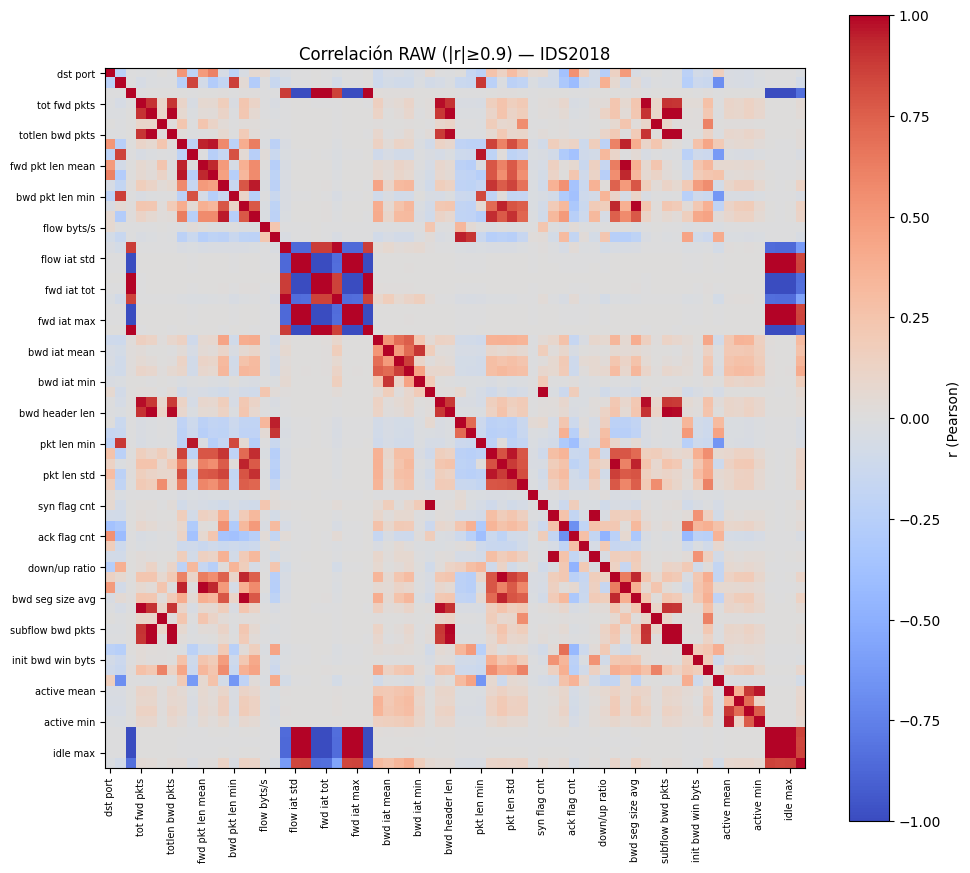

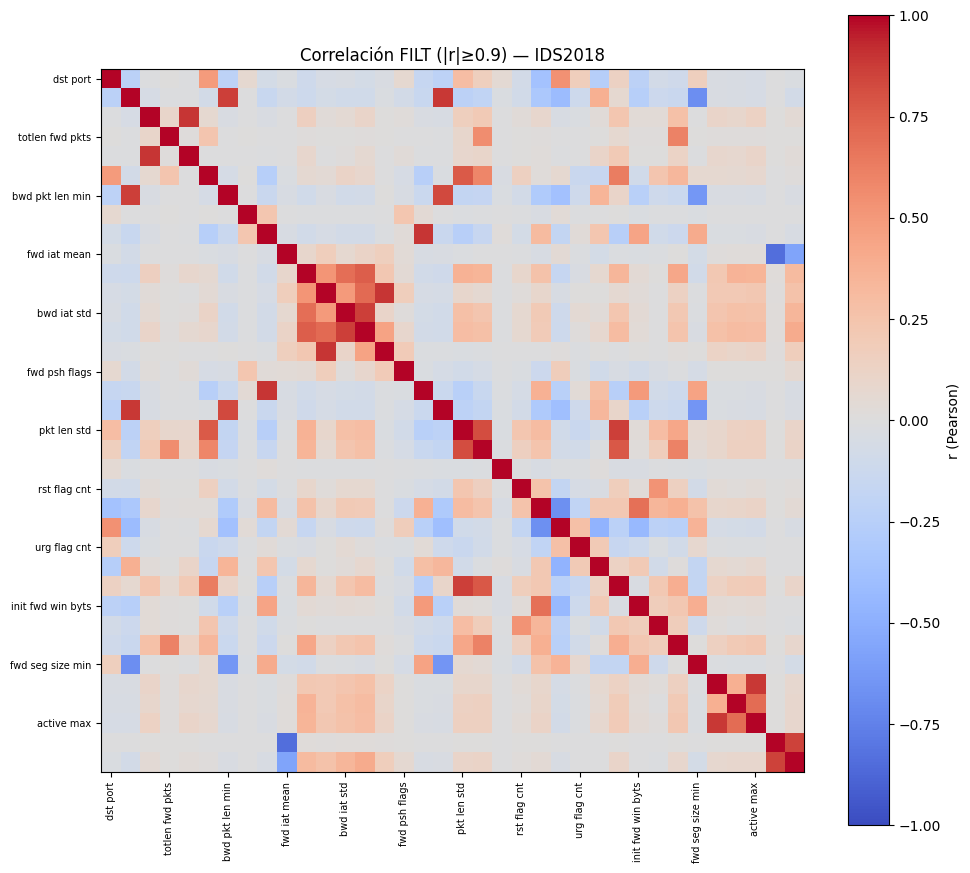

🔗 Pairs |r|≥0.9 — RAW : 97
🔗 Pairs |r|≥0.9 — FILT: 0
🏷️ Top 10 pares (FILT) por |r|:
   - flow pkts/s ↔ bwd pkts/s  | r=0.898
   - bwd iat mean ↔ bwd iat min  | r=0.895
   - tot fwd pkts ↔ totlen bwd pkts  | r=0.892
   - active mean ↔ active max  | r=0.887
   - protocol ↔ pkt len min  | r=0.883
   - bwd iat std ↔ bwd iat max  | r=0.867
   - pkt len std ↔ pkt size avg  | r=0.866
   - protocol ↔ bwd pkt len min  | r=0.862
   - idle mean ↔ idle min  | r=0.854
   - fwd iat mean ↔ idle mean  | r=-0.841
💾 Guardados en: /content/drive/MyDrive/TFG/modelo_guardado_CIC2018
   - corr_heatmap_RAW_IDS2018.png / corr_matrix_RAW_IDS2018.csv
   - corr_heatmap_FILT_IDS2018.png / corr_matrix_FILT_IDS2018.csv


In [ ]:
# ==========================================================
# CELDA 2b — Matriz de correlación (RAW vs FILT) + top pares
# ==========================================================
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from pathlib import Path

assert all(v in globals() for v in ["X_train_raw","FEATURES_RAW","X_train_filt","FEATURES_FILT","MODEL_DIR"])

THR = 0.90  # umbral de redundancia

def corr_mat(X: np.ndarray) -> np.ndarray:
    X = X.astype(np.float64, copy=False)
    Z = (X - X.mean(axis=0)) / (X.std(axis=0) + 1e-12)
    C = (Z.T @ Z) / Z.shape[0]
    return np.clip(C, -1.0, 1.0)

def count_pairs(C: np.ndarray, thr: float) -> int:
    n = C.shape[0]
    iu = np.triu_indices(n, k=1)
    return int((np.abs(C[iu]) >= thr).sum())

def top_pairs(C: np.ndarray, labels: list, k=10):
    n = C.shape[0]
    iu = np.triu_indices(n, k=1)
    vals = np.abs(C[iu])
    idx = np.argsort(-vals)[:k]
    pairs = []
    for t in idx:
        i, j = iu[0][t], iu[1][t]
        pairs.append((labels[i], labels[j], float(C[i, j])))
    return pairs

def save_heatmap(C: np.ndarray, labels: list, title: str, out_png: Path, tick_step=3):
    plt.figure(figsize=(10, 9))
    plt.imshow(C, vmin=-1, vmax=1, cmap="coolwarm", interpolation="nearest")
    plt.colorbar(label="r (Pearson)")
    n = len(labels)
    ticks = np.arange(0, n, max(1, tick_step))
    plt.xticks(ticks, [labels[i] for i in ticks], rotation=90, fontsize=7)
    plt.yticks(ticks, [labels[i] for i in ticks], fontsize=7)
    plt.title(title)
    plt.tight_layout()
    plt.savefig(out_png, dpi=150)
    plt.show()

# --- RAW ---
C_raw = corr_mat(X_train_raw); n_pairs_raw = count_pairs(C_raw, THR)
save_heatmap(C_raw, FEATURES_RAW, f"Correlación RAW (|r|≥{THR}) — IDS2018",
             MODEL_DIR / "corr_heatmap_RAW_IDS2018.png")
pd.DataFrame(C_raw, index=FEATURES_RAW, columns=FEATURES_RAW)\
  .to_csv(MODEL_DIR / "corr_matrix_RAW_IDS2018.csv", index=True)

# --- FILT ---
C_filt = corr_mat(X_train_filt); n_pairs_filt = count_pairs(C_filt, THR)
save_heatmap(C_filt, FEATURES_FILT, f"Correlación FILT (|r|≥{THR}) — IDS2018",
             MODEL_DIR / "corr_heatmap_FILT_IDS2018.png")
pd.DataFrame(C_filt, index=FEATURES_FILT, columns=FEATURES_FILT)\
  .to_csv(MODEL_DIR / "corr_matrix_FILT_IDS2018.csv", index=True)

# --- Top pares correlacionados (después del filtro) ---
top10 = top_pairs(C_filt, FEATURES_FILT, k=10)
print(f"🔗 Pairs |r|≥{THR} — RAW : {n_pairs_raw}")
print(f"🔗 Pairs |r|≥{THR} — FILT: {n_pairs_filt}")
print("🏷️ Top 10 pares (FILT) por |r|:")
for a,b,r in top10:
    print(f"   - {a} ↔ {b}  | r={r:.3f}")

print("💾 Guardados en:", MODEL_DIR)
print("   - corr_heatmap_RAW_IDS2018.png / corr_matrix_RAW_IDS2018.csv")
print("   - corr_heatmap_FILT_IDS2018.png / corr_matrix_FILT_IDS2018.csv")

In [ ]:
# ==========================================================
# CELDA 3 — Ridge + Lasso y selección final (TOP_K)
# ==========================================================
import numpy as np, pandas as pd, json, gc, warnings
from pathlib import Path
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.linear_model import RidgeCV, LassoCV

# Requiere: X_train_filt, X_val_filt, y_train, y_val, FEATURES_FILT, MODEL_DIR
for v in ["X_train_filt","X_val_filt","y_train","y_val","FEATURES_FILT","MODEL_DIR"]:
    assert v in globals(), f"Falta {v}. Ejecuta Celdas 1 y 2."

SEED = 42
np.random.seed(SEED)

# ---------- 1) Muestreo para modelos lineales (control RAM/tiempo) ----------
SAMPLE_FOR_LINEAR = 300_000   # puedes subir/bajar si quieres
if X_train_filt.shape[0] > SAMPLE_FOR_LINEAR:
    frac = SAMPLE_FOR_LINEAR / X_train_filt.shape[0]
    print(f"✂️ Muestreando para lineales ~{SAMPLE_FOR_LINEAR:,} ({frac:.2%})…")
    sss = StratifiedShuffleSplit(n_splits=1, test_size=1-frac, random_state=SEED)
    idx_tr, _ = next(sss.split(np.zeros((y_train.shape[0],1)), y_train))
    X_lin = X_train_filt[idx_tr]
    y_lin = y_train[idx_tr]
else:
    X_lin = X_train_filt
    y_lin = y_train

# Convertir a float64 para estabilidad
X_lin64 = X_lin.astype(np.float64, copy=False)

# ---------- 2) Estandarizar ----------
scaler = StandardScaler(with_mean=True, with_std=True)
X_lin_std = scaler.fit_transform(X_lin64)

# ---------- 3) RIDGE (ranking por magnitud de coeficientes) ----------
ALPHAS_RIDGE = np.logspace(-3, 3, 13)  # 0.001..1000
ridge = RidgeCV(alphas=ALPHAS_RIDGE, cv=3, scoring="neg_mean_squared_error")
ridge.fit(X_lin_std, y_lin.astype(np.float64))
coef_ridge = ridge.coef_
abs_ridge = np.abs(coef_ridge)

ridge_rank_idx   = np.argsort(-abs_ridge)  # descendente
ridge_rank_feats = [FEATURES_FILT[i] for i in ridge_rank_idx]
ridge_rank_vals  = abs_ridge[ridge_rank_idx]

print(f"🏁 RidgeCV alpha*: {ridge.alpha_}")

# ---------- 4) LASSO (sparsity) ----------
warnings.filterwarnings("ignore", category=UserWarning)
lasso = LassoCV(
    eps=1e-3,
    n_alphas=40,
    cv=3,
    max_iter=8000,   # un poco más alto por si tarda en converger
    n_jobs=-1,
    random_state=SEED,
)
lasso.fit(X_lin_std, y_lin.astype(np.float64))
coef_lasso = lasso.coef_
selected_mask = np.abs(coef_lasso) > 1e-8
lasso_selected = [f for f, m in zip(FEATURES_FILT, selected_mask) if m]

print(f"🏁 LassoCV alpha*: {lasso.alpha_}")
print(f"✔️ Lasso seleccionó {len(lasso_selected)} features")

# ---------- 5) Ensamblar set final ----------
TOP_K = 27  # como en UNSW (ajustable)
final_feats = list(lasso_selected)

if len(final_feats) > TOP_K:
    # ordenar las de Lasso usando ranking de Ridge
    order_map = {f:i for i,f in enumerate(ridge_rank_feats)}
    final_feats = sorted(final_feats, key=lambda f: order_map.get(f, 10**9))[:TOP_K]
elif len(final_feats) < TOP_K:
    for f in ridge_rank_feats:
        if f not in final_feats:
            final_feats.append(f)
            if len(final_feats) == TOP_K:
                break

print(f"🎯 Features finales (TOP_K={TOP_K}): {len(final_feats)}")
print("   Top 10 finales:", final_feats[:10])

# ---------- 6) Guardar artefactos ----------
MODEL_DIR.mkdir(parents=True, exist_ok=True)

# tabla con coeficientes
pd.DataFrame({
    "feature": FEATURES_FILT,
    "ridge_abs_coef": np.abs(coef_ridge),
    "lasso_coef": coef_lasso,
    "selected_by_lasso": selected_mask.astype(int),
}).to_csv(MODEL_DIR / "features_ridge_lasso_table_IDS2018.csv", index=False)

# ranking ridge completo
pd.DataFrame({
    "feature": ridge_rank_feats,
    "abs_coef": ridge_rank_vals
}).to_csv(MODEL_DIR / "features_rank_ridge_IDS2018.csv", index=False)

# listas clave
with open(MODEL_DIR / "features_selected_lasso_IDS2018.json", "w") as f:
    json.dump(lasso_selected, f, indent=2)

with open(MODEL_DIR / "features_final_IDS2018.json", "w") as f:
    json.dump(final_feats, f, indent=2)

# dejar en RAM por si quieres seguir
FEATURES_FINAL = final_feats
RIDGE_COEF = coef_ridge
LASSO_COEF = coef_lasso

print("💾 Guardados en:", MODEL_DIR)
print("   - features_ridge_lasso_table_IDS2018.csv")
print("   - features_rank_ridge_IDS2018.csv")
print("   - features_selected_lasso_IDS2018.json")
print("   - features_final_IDS2018.json")

gc.collect()

✂️ Muestreando para lineales ~300,000 (50.00%)…
🏁 RidgeCV alpha*: 1000.0
🏁 LassoCV alpha*: 0.003256653173252376
✔️ Lasso seleccionó 24 features
🎯 Features finales (TOP_K=27): 27
   Top 10 finales: ['dst port', 'protocol', 'totlen fwd pkts', 'totlen bwd pkts', 'fwd pkt len mean', 'flow byts/s', 'fwd iat mean', 'bwd iat tot', 'bwd iat mean', 'bwd iat std']
💾 Guardados en: /content/drive/MyDrive/TFG/modelo_guardado_CIC2018
   - features_ridge_lasso_table_IDS2018.csv
   - features_rank_ridge_IDS2018.csv
   - features_selected_lasso_IDS2018.json
   - features_final_IDS2018.json


14986

In [ ]:
# ==========================================================
# CELDA 3b — Mostrar variables definitivas (TopK y Consenso)
# ==========================================================
import json, pandas as pd
from pathlib import Path

assert 'MODEL_DIR' in globals(), "Ejecuta antes las celdas previas."

p_topk = MODEL_DIR / "features_final_IDS2018.json"
p_cons = MODEL_DIR / "features_final_consensus_IDS2018.json"
assert p_topk.exists(), "Falta features_final_IDS2018.json (Celda 3)."
assert p_cons.exists(), "Falta features_final_consensus_IDS2018.json (Celda 4)."

feat_topk = json.loads(p_topk.read_text())
feat_cons = json.loads(p_cons.read_text())

print(f"🧱 TopK (Celda 3): {len(feat_topk)} features")
for i, f in enumerate(feat_topk, 1):
    print(f"{i:2d}. {f}")

print("\n🧱 Consenso (Celda 4): {0} features".format(len(feat_cons)))
for i, f in enumerate(feat_cons, 1):
    print(f"{i:2d}. {f}")

# Resumen rápido
topk_set, cons_set = set(feat_topk), set(feat_cons)
print("\n📌 Intersección:", len(topk_set & cons_set))
print("📌 Solo en TopK :", len(topk_set - cons_set))
print("📌 Solo en Cons.:", len(cons_set - topk_set))
print("📌 Jaccard      :", round(len(topk_set & cons_set)/len(topk_set | cons_set), 3))


🧱 TopK (Celda 3): 27 features
 1. dst port
 2. protocol
 3. totlen fwd pkts
 4. totlen bwd pkts
 5. fwd pkt len mean
 6. flow byts/s
 7. fwd iat mean
 8. bwd iat tot
 9. bwd iat mean
10. bwd iat std
11. fwd psh flags
12. bwd pkts/s
13. pkt len min
14. pkt len var
15. fin flag cnt
16. psh flag cnt
17. ack flag cnt
18. urg flag cnt
19. init fwd win byts
20. init bwd win byts
21. fwd act data pkts
22. fwd seg size min
23. active mean
24. active std
25. idle mean
26. idle min
27. flow pkts/s

🧱 Consenso (Celda 4): 27 features
 1. dst port
 2. protocol
 3. totlen fwd pkts
 4. totlen bwd pkts
 5. fwd pkt len mean
 6. flow byts/s
 7. fwd iat mean
 8. bwd iat tot
 9. bwd iat mean
10. bwd iat std
11. fwd psh flags
12. bwd pkts/s
13. pkt len min
14. fin flag cnt
15. psh flag cnt
16. ack flag cnt
17. urg flag cnt
18. init fwd win byts
19. init bwd win byts
20. fwd act data pkts
21. fwd seg size min
22. flow pkts/s
23. active mean
24. pkt len var
25. idle mean
26. active std
27. idle min

📌 Inters

In [ ]:
# ==========================================================
# CELDA 3c — Tabla consolidada de importancia (TopK/Consenso)
# ==========================================================
import json, pandas as pd, numpy as np
from pathlib import Path

# Cargas
p_topk = MODEL_DIR / "features_final_IDS2018.json"
p_cons = MODEL_DIR / "features_final_consensus_IDS2018.json"
p_rl   = MODEL_DIR / "features_ridge_lasso_table_IDS2018.csv"  # Celda 3
p_stab = MODEL_DIR / "features_stability_IDS2018.csv"          # Celda 4
p_perm = MODEL_DIR / "features_permutation_importance_IDS2018.csv"  # Celda 4

feat_topk = json.loads(p_topk.read_text())
feat_cons = json.loads(p_cons.read_text())

df = pd.DataFrame({"feature": list(dict.fromkeys(feat_cons + feat_topk))})
df["in_consensus"] = df["feature"].isin(feat_cons).astype(int)
df["in_topk"]      = df["feature"].isin(feat_topk).astype(int)

# Merge con coeficientes Ridge/Lasso (abs)
if p_rl.exists():
    rl = pd.read_csv(p_rl)
    rl = rl.rename(columns={"ridge_abs_coef":"ridge_abs", "lasso_coef":"lasso"})
    df = df.merge(rl[["feature","ridge_abs","lasso","selected_by_lasso"]], on="feature", how="left")

# Merge con Stability
if p_stab.exists():
    stab = pd.read_csv(p_stab)
    df = df.merge(stab, on="feature", how="left")

# Merge con Permutation Importance
if p_perm.exists():
    pi = pd.read_csv(p_perm)
    df = df.merge(pi[["feature","perm_import_mean","perm_import_std"]], on="feature", how="left")

# Orden sugerido: consenso primero, luego importancia promedio
imp_proxy = np.nan_to_num(df["ridge_abs"], 0) + np.nan_to_num(df["lasso"].abs(), 0) + np.nan_to_num(df["perm_import_mean"], 0)
df["imp_proxy"] = imp_proxy
df = df.sort_values(["in_consensus","imp_proxy"], ascending=[False, False])

cols_show = ["feature","in_consensus","in_topk","ridge_abs","lasso","selected_by_lasso",
             "stability_freq","perm_import_mean","perm_import_std"]
display(df[cols_show].reset_index(drop=True).head(40))

# Guardados
out_csv = MODEL_DIR / "features_summary_table_IDS2018.csv"
out_md  = MODEL_DIR / "features_summary_table_IDS2018.md"
df[cols_show].to_csv(out_csv, index=False)

# pequeño markdown para pegar en el TFG
with open(out_md, "w") as f:
    f.write("| Feature | In Consenso | In TopK | Ridge | Lasso | Sel Lasso | Stability | PermImp |\n")
    f.write("|---|---:|---:|---:|---:|---:|---:|---:|\n")
    for _,r in df[cols_show].iterrows():
        f.write(f"| {r['feature']} | {int(r['in_consensus'])} | {int(r['in_topk'])} | "
                f"{(r['ridge_abs'] if pd.notna(r['ridge_abs']) else 0):.4g} | "
                f"{(abs(r['lasso']) if pd.notna(r['lasso']) else 0):.4g} | "
                f"{int(r['selected_by_lasso']) if pd.notna(r['selected_by_lasso']) else 0} | "
                f"{(r['stability_freq'] if pd.notna(r['stability_freq']) else 0):.2f} | "
                f"{(r['perm_import_mean'] if pd.notna(r['perm_import_mean']) else 0):.4g} |\n")

print("💾 Guardados:")
print(" -", out_csv)
print(" -", out_md, "(tabla Markdown para el informe)")


,feature,in_consensus,in_topk,ridge_abs,lasso,selected_by_lasso,stability_freq,perm_import_mean,perm_import_std
0,fwd seg size min,1,1,0.505583,0.475248,1,1.0,0.295353,0.000689
1,psh flag cnt,1,1,0.356910,-0.228716,1,1.0,0.000000,0.000000
2,dst port,1,1,0.182191,-0.180824,1,1.0,0.198842,0.000968
3,ack flag cnt,1,1,0.267765,-0.151067,1,1.0,0.000000,0.000000
4,fwd pkt len mean,1,1,0.157363,-0.138831,1,1.0,0.000004,0.000003
5,fwd act data pkts,1,1,0.123532,0.099309,1,1.0,-0.000002,0.000003
6,fwd iat mean,1,1,0.078702,-0.003072,1,1.0,0.055776,0.000189
7,bwd iat tot,1,1,0.067545,-0.054914,1,1.0,0.000000,0.000000
8,protocol,1,1,0.100955,-0.012963,1,1.0,0.000000,0.000000
9,idle mean,1,1,0.108068,-0.000000,0,0.0,0.000000,0.000000


💾 Guardados:
 - /content/drive/MyDrive/TFG/modelo_guardado_CIC2018/features_summary_table_IDS2018.csv
 - /content/drive/MyDrive/TFG/modelo_guardado_CIC2018/features_summary_table_IDS2018.md (tabla Markdown para el informe)


In [ ]:
# ==========================================================
# CELDA 4 — Stability Selection + Permutation Importance + CONSENSO
# ==========================================================
import numpy as np, pandas as pd, json, gc, warnings
from pathlib import Path
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LassoCV, Lasso
from sklearn.inspection import permutation_importance
from sklearn.ensemble import HistGradientBoostingClassifier

# Requiere: X_train_filt, X_val_filt, y_train, y_val, FEATURES_FILT, FEATURES_FINAL, MODEL_DIR
for v in ["X_train_filt","X_val_filt","y_train","y_val","FEATURES_FILT","FEATURES_FINAL","MODEL_DIR"]:
    assert v in globals(), f"Falta {v}. Ejecuta Celda 1-3 primero."

SEED = 42
np.random.seed(SEED)

# ---------- 1) Preparar subset para Stability Selection ----------
N_STAB = 200_000  # tamaño de muestra para estabilidad (sube/baja según RAM/tiempo)
if X_train_filt.shape[0] > N_STAB:
    frac = N_STAB / X_train_filt.shape[0]
    print(f"✂️ Submuestreando para Stability Selection ~{N_STAB:,} ({frac:.2%})…")
    sss_base = StratifiedShuffleSplit(n_splits=1, test_size=1-frac, random_state=SEED)
    idx_tr, _ = next(sss_base.split(np.zeros((y_train.shape[0],1)), y_train))
    X_stab = X_train_filt[idx_tr].astype(np.float64, copy=False)
    y_stab = y_train[idx_tr]
else:
    X_stab = X_train_filt.astype(np.float64, copy=False)
    y_stab = y_train

# Estandarización para Lasso
scaler_stab = StandardScaler()
X_stab_std = scaler_stab.fit_transform(X_stab)

# ---------- 2) Alpha óptimo con LassoCV (una vez) ----------
warnings.filterwarnings("ignore", category=UserWarning)
lasso_cv = LassoCV(
    eps=1e-3, n_alphas=40, cv=3, max_iter=5000, n_jobs=-1, random_state=SEED
).fit(X_stab_std, y_stab.astype(np.float64))
alpha_opt = float(lasso_cv.alpha_)
print(f"🏁 Alpha óptimo para Stability Selection (LassoCV): {alpha_opt}")

# ---------- 3) Stability Selection (repetir Lasso en submuestras) ----------
REPEATS = 10         # nº de repeticiones
SUB_FRAC = 0.75      # fracción de datos en cada repetición
sel_counts = np.zeros(X_stab.shape[1], dtype=np.int32)

sss = StratifiedShuffleSplit(n_splits=REPEATS, test_size=1-SUB_FRAC, random_state=SEED)
for r, (idx_sub, _) in enumerate(sss.split(np.zeros((y_stab.shape[0],1)), y_stab), start=1):
    X_sub = X_stab[idx_sub]
    y_sub = y_stab[idx_sub]
    X_sub_std = scaler_stab.transform(X_sub)  # usar el scaler base para estabilidad
    lasso = Lasso(alpha=alpha_opt, max_iter=5000, random_state=SEED+r)
    lasso.fit(X_sub_std, y_sub.astype(np.float64))
    sel_counts += (np.abs(lasso.coef_) > 1e-8).astype(np.int32)
    if r % 2 == 0:
        print(f"   · Repetición {r}/{REPEATS} completada")

sel_freq = sel_counts / REPEATS
stab_df = pd.DataFrame({
    "feature": FEATURES_FILT,
    "stability_freq": sel_freq
}).sort_values("stability_freq", ascending=False)
stab_df.to_csv(MODEL_DIR / "features_stability_IDS2018.csv", index=False)
print("💾 Guardado stability table → features_stability_IDS2018.csv")

STAB_THR = 0.60  # umbral de estabilidad (≥60%)
stable_feats = stab_df.loc[stab_df["stability_freq"] >= STAB_THR, "feature"].tolist()
print(f"🧷 Features estables (≥{int(STAB_THR*100)}%): {len(stable_feats)}")

# ---------- 4) Permutation Importance (val) con modelo ligero ----------
# Construir X_val con las columnas filtradas de Celda 2 (FEATURES_FILT)
feat2idx = {f:i for i,f in enumerate(FEATURES_FILT)}

# Usaremos el consenso provisional (union de estables y finales) para el modelo
union_feats = list(dict.fromkeys(list(stable_feats) + list(FEATURES_FINAL)))
idx_union = [feat2idx[f] for f in union_feats if f in feat2idx]
X_val_union = X_val_filt[:, idx_union].astype(np.float64, copy=False)

# Submuestreo de val para no tardar demasiado en permutation
N_VAL_PI = min(150_000, X_val_union.shape[0])
if X_val_union.shape[0] > N_VAL_PI:
    # muestreo estratificado sobre y_val
    frac_val = N_VAL_PI / X_val_union.shape[0]
    sss_val = StratifiedShuffleSplit(n_splits=1, test_size=1-frac_val, random_state=SEED)
    idx_v, _ = next(sss_val.split(np.zeros((y_val.shape[0],1)), y_val))
    X_val_pi = X_val_union[idx_v]
    y_val_pi = y_val[idx_v]
else:
    X_val_pi = X_val_union
    y_val_pi = y_val

hgb = HistGradientBoostingClassifier(random_state=SEED)
hgb.fit(X_stab[:, idx_union], y_stab)  # entrenamos en el subset de train estabilidad
pi = permutation_importance(
    hgb, X_val_pi, y_val_pi, n_repeats=3, random_state=SEED, n_jobs=-1
)

pi_df = pd.DataFrame({
    "feature": union_feats,
    "perm_import_mean": pi.importances_mean,
    "perm_import_std":  pi.importances_std
}).sort_values("perm_import_mean", ascending=False)
pi_df.to_csv(MODEL_DIR / "features_permutation_importance_IDS2018.csv", index=False)
print("💾 Guardado permutation importance → features_permutation_importance_IDS2018.csv")

# ---------- 5) CONSENSO TOP_K ----------
TOP_K = 27  # mismo K que en Celda 3
# (a) intersección entre finales (Celda 3) y estables
consensus = [f for f in FEATURES_FINAL if f in stable_feats]

# (b) si faltan para TOP_K, rellenar con las mejores por permutation (que no estén ya)
if len(consensus) < TOP_K:
    for f in pi_df["feature"].tolist():
        if f not in consensus:
            consensus.append(f)
            if len(consensus) == TOP_K:
                break

print(f"🎯 CONSENSO TOP_K={TOP_K}: {len(consensus)} features")
print("   Top 10 consenso:", consensus[:10])

with open(MODEL_DIR / "features_final_consensus_IDS2018.json", "w") as f:
    json.dump(consensus, f, indent=2)

print("💾 Guardados en:", MODEL_DIR)
print("   - features_stability_IDS2018.csv")
print("   - features_permutation_importance_IDS2018.csv")
print("   - features_final_consensus_IDS2018.json")

gc.collect()

✂️ Submuestreando para Stability Selection ~200,000 (33.33%)…
🏁 Alpha óptimo para Stability Selection (LassoCV): 0.0027289525416896
   · Repetición 2/10 completada
   · Repetición 4/10 completada
   · Repetición 6/10 completada
   · Repetición 8/10 completada
   · Repetición 10/10 completada
💾 Guardado stability table → features_stability_IDS2018.csv
🧷 Features estables (≥60%): 21
💾 Guardado permutation importance → features_permutation_importance_IDS2018.csv
🎯 CONSENSO TOP_K=27: 27 features
   Top 10 consenso: ['dst port', 'protocol', 'totlen fwd pkts', 'totlen bwd pkts', 'fwd pkt len mean', 'flow byts/s', 'fwd iat mean', 'bwd iat tot', 'bwd iat mean', 'bwd iat std']
💾 Guardados en: /content/drive/MyDrive/TFG/modelo_guardado_CIC2018
   - features_stability_IDS2018.csv
   - features_permutation_importance_IDS2018.csv
   - features_final_consensus_IDS2018.json


84

In [ ]:
# ==========================================================
# CELDA 5 — Validación de sets de variables (ROC-AUC, PR-AUC, F1)
# ==========================================================
import json, gc, numpy as np, pandas as pd
from pathlib import Path
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score, average_precision_score, precision_recall_curve, f1_score
from sklearn.model_selection import StratifiedShuffleSplit

# Requiere de celdas previas:
for v in ["X_train_filt","X_val_filt","y_train","y_val","FEATURES_FILT","MODEL_DIR"]:
    assert v in globals(), f"Falta {v} — ejecuta Celdas 1-4."

# Cargar features finales Top-K (Celda 3) y consenso (Celda 4)
# (si no existen en RAM, los leemos del disco)
if 'FEATURES_FINAL' not in globals():
    p = MODEL_DIR / "features_final_IDS2018.json"
    assert p.exists(), "No encuentro features_final_IDS2018.json"
    FEATURES_FINAL = json.loads(p.read_text())

try:
    if 'consensus' not in globals():
        p_cons = MODEL_DIR / "features_final_consensus_IDS2018.json"
        consensus = json.loads(p_cons.read_text())
except Exception:
    consensus = FEATURES_FINAL[:]  # fallback

# Mapeo nombre->índice sobre el espacio filtrado (Celda 2)
feat2idx = {f:i for i, f in enumerate(FEATURES_FILT)}
def cols_idx(names):
    missing = [f for f in names if f not in feat2idx]
    if missing:
        print(f"⚠️ Aviso: {len(missing)} features no están en FEATURES_FILT y se omiten:", missing[:8], "...")
    return [feat2idx[f] for f in names if f in feat2idx]

SETS = {
    "All_filtered": FEATURES_FILT,
    "TopK_Celda3": FEATURES_FINAL,
    "TopK_Consensus_Celda4": consensus,
}

# Muestreo opcional para el ajuste (para acelerar)
N_TRAIN_FIT = min(500_000, X_train_filt.shape[0])  # sube/baja si quieres
if X_train_filt.shape[0] > N_TRAIN_FIT:
    frac = N_TRAIN_FIT / X_train_filt.shape[0]
    print(f"✂️ Muestreo para ajuste ~{N_TRAIN_FIT:,} ({frac:.2%})…")
    sss = StratifiedShuffleSplit(n_splits=1, test_size=1-frac, random_state=42)
    idx_fit, _ = next(sss.split(np.zeros((y_train.shape[0],1)), y_train))
else:
    idx_fit = np.arange(X_train_filt.shape[0])

def eval_set(name, feat_names):
    idx = cols_idx(feat_names)
    Xtr = X_train_filt[idx_fit][:, idx].astype(np.float32, copy=False)
    ytr = y_train[idx_fit]
    Xva = X_val_filt[:, idx].astype(np.float32, copy=False)
    yva = y_val

    # Pipeline: z-score + LR (saga) con balanceo
    pipe = Pipeline([
        ("scaler", StandardScaler(with_mean=True, with_std=True)),
        ("lr", LogisticRegression(
            solver="saga",
            penalty="l2",
            C=1.0,
            class_weight="balanced",
            max_iter=400,
            n_jobs=-1,
            random_state=42
        ))
    ])
    pipe.fit(Xtr, ytr)
    # Probabilidades
    try:
        p = pipe.predict_proba(Xva)[:, 1]
    except Exception:
        # fallback si no hay predict_proba (no debería ocurrir con LR)
        p = pipe.decision_function(Xva)
        p = (p - p.min()) / (p.max() - p.min() + 1e-12)

    # Métricas
    roc = roc_auc_score(yva, p)
    ap  = average_precision_score(yva, p)

    # F1 en 0.5 y F1 máximo
    yhat_05 = (p >= 0.5).astype(int)
    f1_05   = f1_score(yva, yhat_05)

    pr_prec, pr_rec, pr_thr = precision_recall_curve(yva, p)
    # thresholds alínean con pares (prec, rec) excepto el último punto
    f1s = 2*pr_prec[:-1]*pr_rec[:-1] / (pr_prec[:-1] + pr_rec[:-1] + 1e-12)
    best_idx = int(np.nanargmax(f1s))
    f1_best  = float(f1s[best_idx])
    thr_best = float(pr_thr[best_idx])

    # Coefs absolutas ordenadas (para informe)
    lr = pipe.named_steps["lr"]
    coefs = np.abs(lr.coef_.ravel())
    order = np.argsort(-coefs)
    top_coef = [(feat_names[i], float(coefs[i])) for i in order[:min(20, len(order))]]

    return {
        "set": name,
        "n_features": len(idx),
        "roc_auc": roc,
        "pr_auc": ap,
        "f1@0.5": f1_05,
        "f1@best": f1_best,
        "thr_best": thr_best,
        "top_coef": top_coef,
        "coef_full": {feat_names[i]: float(coefs[i]) for i in range(len(idx))}
    }

results = []
for name, feats in SETS.items():
    print(f"\n🔎 Evaluando set: {name}  (n={len(feats)})")
    res = eval_set(name, feats)
    results.append(res)
    print(f"   ROC-AUC={res['roc_auc']:.4f} | PR-AUC={res['pr_auc']:.4f} | F1@0.5={res['f1@0.5']:.4f} | F1@best={res['f1@best']:.4f} (τ*={res['thr_best']:.3f})")
    print("   Top 5 por |coef|:", [t[0] for t in res["top_coef"][:5]])

# Tabla resumen
df_sum = pd.DataFrame([{
    "set": r["set"],
    "n_features": r["n_features"],
    "roc_auc": r["roc_auc"],
    "pr_auc": r["pr_auc"],
    "f1@0.5": r["f1@0.5"],
    "f1@best": r["f1@best"],
    "thr_best": r["thr_best"],
} for r in results]).sort_values("roc_auc", ascending=False)

print("\n✅ Validación comparativa terminada")
display(df_sum)

# Guardar artefactos
MODEL_DIR.mkdir(parents=True, exist_ok=True)
df_sum.to_csv(MODEL_DIR / "validation_feature_sets_IDS2018.csv", index=False)

# Guardar coeficientes por set (para informe)
for r in results:
    pd.Series(r["coef_full"]).to_csv(MODEL_DIR / f"coef_{r['set']}_LR_IDS2018.csv", header=["abs_coef"])

print("💾 Guardados en:", MODEL_DIR)
print("   - validation_feature_sets_IDS2018.csv")
print("   - coef_*_LR_IDS2018.csv")

gc.collect()

✂️ Muestreo para ajuste ~500,000 (83.33%)…

🔎 Evaluando set: All_filtered  (n=36)
   ROC-AUC=0.9952 | PR-AUC=0.9866 | F1@0.5=0.9783 | F1@best=0.9823 (τ*=0.595)
   Top 5 por |coef|: ['fwd seg size min', 'dst port', 'bwd pkts/s', 'fwd pkt len mean', 'init fwd win byts']

🔎 Evaluando set: TopK_Celda3  (n=27)
   ROC-AUC=0.9955 | PR-AUC=0.9871 | F1@0.5=0.9792 | F1@best=0.9846 (τ*=0.646)
   Top 5 por |coef|: ['fwd seg size min', 'dst port', 'fwd pkt len mean', 'bwd pkts/s', 'init fwd win byts']

🔎 Evaluando set: TopK_Consensus_Celda4  (n=27)
   ROC-AUC=0.9955 | PR-AUC=0.9871 | F1@0.5=0.9792 | F1@best=0.9846 (τ*=0.646)
   Top 5 por |coef|: ['fwd seg size min', 'dst port', 'fwd pkt len mean', 'bwd pkts/s', 'init fwd win byts']

✅ Validación comparativa terminada


,set,n_features,roc_auc,pr_auc,f1@0.5,f1@best,thr_best
2,TopK_Consensus_Celda4,27,0.995476,0.987058,0.979208,0.984565,0.646072
1,TopK_Celda3,27,0.995476,0.987058,0.979208,0.984565,0.646075
0,All_filtered,36,0.995236,0.986551,0.978296,0.982323,0.594979


💾 Guardados en: /content/drive/MyDrive/TFG/modelo_guardado_CIC2018
   - validation_feature_sets_IDS2018.csv
   - coef_*_LR_IDS2018.csv


31

📊 Tabla (5 decimales):


,set,n_features,roc_auc,pr_auc,f1@0.5,f1@best,thr_best,ΔROC (‰),ΔPR (‰)
0,TopK_Consensus_Celda4,27,0.99548,0.98706,0.97921,0.98456,0.646,0.00,0.00
1,TopK_Celda3,27,0.99548,0.98706,0.97921,0.98456,0.646,-0.00,-0.00
2,All_filtered,36,0.99524,0.98655,0.97830,0.98232,0.595,-0.24,-0.51


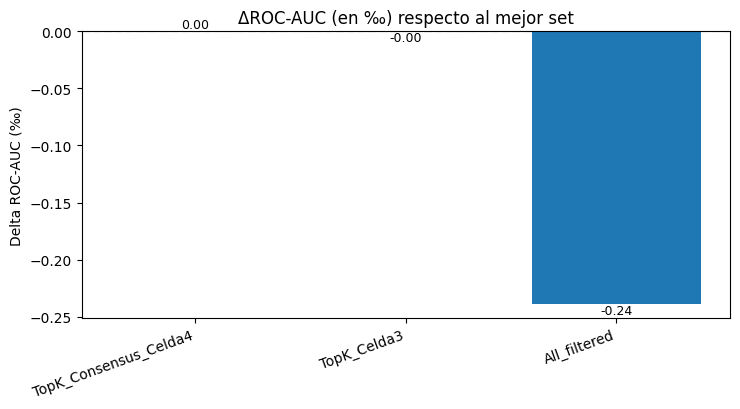

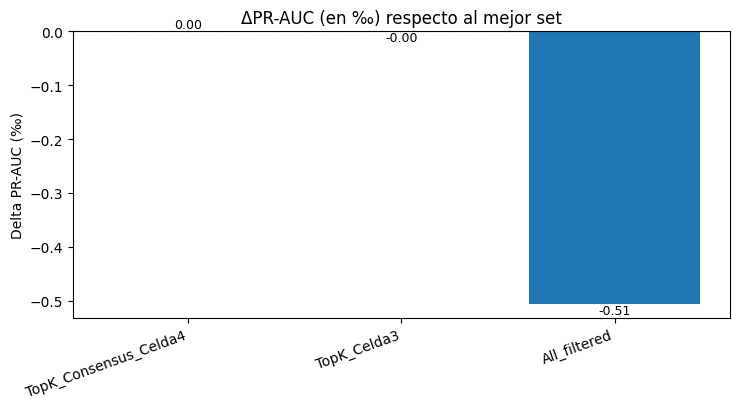

🖼️ Guardado Δ-plots en:
 - /content/drive/MyDrive/TFG/modelo_guardado_CIC2018/plot_delta_roc_per_mille_IDS2018.png
 - /content/drive/MyDrive/TFG/modelo_guardado_CIC2018/plot_delta_pr_per_mille_IDS2018.png


2778

In [ ]:
# ==========================================================
# CELDA 6 — Deltas (‰) + tabla detallada
# ==========================================================
import json, gc
import numpy as np, pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

if 'MODEL_DIR' not in globals():
    MODEL_DIR = Path("/content/drive/MyDrive/TFG/modelo_guardado_CIC2018")
VAL_SUM_CSV = MODEL_DIR / "validation_feature_sets_IDS2018.csv"
assert VAL_SUM_CSV.exists(), "Falta validation_feature_sets_IDS2018.csv (ejecuta Celda 5)."

df = pd.read_csv(VAL_SUM_CSV)

# Ordena por ROC-AUC y añade más decimales + deltas (per-mille)
df = df.sort_values('roc_auc', ascending=False).reset_index(drop=True)
for col in ['roc_auc','pr_auc','f1@0.5','f1@best','thr_best']:
    df[col] = df[col].astype(float)
best_roc = df['roc_auc'].max()
best_pr  = df['pr_auc'].max()
df['ΔROC (‰)'] = (df['roc_auc'] - best_roc) * 1000.0   # mejor = 0.0
df['ΔPR  (‰)'] = (df['pr_auc']  - best_pr)  * 1000.0

print("📊 Tabla (5 decimales):")
display(df[['set','n_features',
            'roc_auc','pr_auc','f1@0.5','f1@best','thr_best','ΔROC (‰)','ΔPR  (‰)']].style.format({
    'roc_auc': '{:.5f}', 'pr_auc': '{:.5f}', 'f1@0.5': '{:.5f}', 'f1@best': '{:.5f}',
    'thr_best': '{:.3f}', 'ΔROC (‰)': '{:.2f}', 'ΔPR  (‰)': '{:.2f}'
}))

# ---- Gráfico: delta ROC en ‰ (cuanto más cerca de 0, mejor)
plt.figure(figsize=(7.5, 4.2))
plt.title("ΔROC-AUC (en ‰) respecto al mejor set")
plt.bar(df['set'], df['ΔROC (‰)'])
plt.axhline(0, linestyle='--')
for i, v in enumerate(df['ΔROC (‰)']):
    plt.text(i, v, f"{v:.2f}", ha='center', va='bottom' if v>=0 else 'top', fontsize=9, rotation=0)
plt.xticks(rotation=20, ha='right')
plt.ylabel("Delta ROC-AUC (‰)")
plt.tight_layout()
plt.savefig(MODEL_DIR / "plot_delta_roc_per_mille_IDS2018.png", dpi=140)
plt.show()

# ---- Gráfico: delta PR-AUC en ‰
plt.figure(figsize=(7.5, 4.2))
plt.title("ΔPR-AUC (en ‰) respecto al mejor set")
plt.bar(df['set'], df['ΔPR  (‰)'])
plt.axhline(0, linestyle='--')
for i, v in enumerate(df['ΔPR  (‰)']):
    plt.text(i, v, f"{v:.2f}", ha='center', va='bottom' if v>=0 else 'top', fontsize=9, rotation=0)
plt.xticks(rotation=20, ha='right')
plt.ylabel("Delta PR-AUC (‰)")
plt.tight_layout()
plt.savefig(MODEL_DIR / "plot_delta_pr_per_mille_IDS2018.png", dpi=140)
plt.show()

print("🖼️ Guardado Δ-plots en:")
print(" -", MODEL_DIR / "plot_delta_roc_per_mille_IDS2018.png")
print(" -", MODEL_DIR / "plot_delta_pr_per_mille_IDS2018.png")
gc.collect()

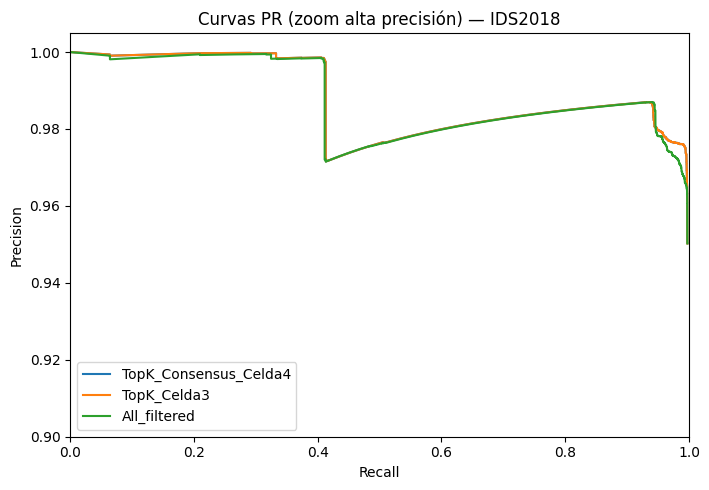

🖼️ Guardado: /content/drive/MyDrive/TFG/modelo_guardado_CIC2018/plot_pr_zoom_high_precision_IDS2018.png


In [ ]:
# ==========================================================
# CELDA 7 — PR curves (zoom alta precisión) para los 3 sets
# ==========================================================
import numpy as np, pandas as pd
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

# Requiere objetos de Celdas 1–5
for v in ["X_train_filt","X_val_filt","y_train","y_val","FEATURES_FILT","MODEL_DIR"]:
    assert v in globals(), f"Falta {v}."

import json
SETS = {}
# cargamos listas
SETS["TopK_Consensus_Celda4"] = json.loads((MODEL_DIR / "features_final_consensus_IDS2018.json").read_text())
SETS["TopK_Celda3"]          = json.loads((MODEL_DIR / "features_final_IDS2018.json").read_text())
SETS["All_filtered"]         = list(FEATURES_FILT)

feat2idx = {f:i for i,f in enumerate(FEATURES_FILT)}

def idx_of(names): return [feat2idx[f] for f in names if f in feat2idx]

# Submuestreo para entrenar y para predecir (rápido)
N_TR = min(300_000, X_train_filt.shape[0])
N_VA = min(150_000, X_val_filt.shape[0])

sss_tr = StratifiedShuffleSplit(n_splits=1, test_size=1-N_TR/X_train_filt.shape[0], random_state=42)
idx_tr, _ = next(sss_tr.split(np.zeros((y_train.shape[0],1)), y_train))
sss_va = StratifiedShuffleSplit(n_splits=1, test_size=1-N_VA/X_val_filt.shape[0], random_state=42)
idx_va, _ = next(sss_va.split(np.zeros((y_val.shape[0],1)), y_val))

plt.figure(figsize=(7.2, 5.0))
plt.title("Curvas PR (zoom alta precisión) — IDS2018")
for name, feats in SETS.items():
    cols = idx_of(feats)
    Xtr = X_train_filt[idx_tr][:, cols]
    ytr = y_train[idx_tr]
    Xva = X_val_filt[idx_va][:, cols]
    yva = y_val[idx_va]

    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("lr", LogisticRegression(solver="saga", penalty="l2", C=1.0,
                                  class_weight="balanced", max_iter=400, n_jobs=-1, random_state=42))
    ]).fit(Xtr, ytr)

    p = pipe.predict_proba(Xva)[:, 1]
    prec, rec, _ = precision_recall_curve(yva, p)

    # filtrar a región de precisión alta
    mask = prec >= 0.95
    if mask.sum() < 2:  # si casi no hay puntos ≥0.95, relajar a 0.90
        mask = prec >= 0.90
    plt.plot(rec[mask], prec[mask], label=f"{name}")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.xlim(0, 1)
plt.ylim(0.90, 1.005)  # zoom
plt.legend()
plt.tight_layout()
out_path = MODEL_DIR / "plot_pr_zoom_high_precision_IDS2018.png"
plt.savefig(out_path, dpi=140)
plt.show()
print("🖼️ Guardado:", out_path)

In [ ]:
# ==========================================================
# CELDA 8 — Lock de listas y versiones (reproducibilidad)
# ==========================================================
import json, platform, sklearn, numpy as np, pandas as pd, datetime as dt
from pathlib import Path

lock = {
    "timestamp": dt.datetime.utcnow().isoformat() + "Z",
    "features_topk": json.loads((MODEL_DIR/"features_final_IDS2018.json").read_text()),
    "features_consensus": json.loads((MODEL_DIR/"features_final_consensus_IDS2018.json").read_text()),
    "versions": {
        "python": platform.python_version(),
        "numpy": np.__version__,
        "pandas": pd.__version__,
        "sklearn": sklearn.__version__,
    }
}
with open(MODEL_DIR/"features_lock_IDS2018.json","w") as f:
    json.dump(lock, f, indent=2)
print("🔒 Lock guardado en:", MODEL_DIR/"features_lock_IDS2018.json")


🔒 Lock guardado en: /content/drive/MyDrive/TFG/modelo_guardado_CIC2018/features_lock_IDS2018.json


/tmp/ipython-input-2393731457.py:8: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "timestamp": dt.datetime.utcnow().isoformat() + "Z",


In [ ]:
# ==========================================================
# CELDA 9 — Helper: seleccionar columnas por lista (topk/consenso)
# ==========================================================
import json
from typing import Literal

def subset_by_list(df: pd.DataFrame, which: Literal["topk","consenso"]="consenso"):
    path = MODEL_DIR / ("features_final_IDS2018.json" if which=="topk"
                        else "features_final_consensus_IDS2018.json")
    names = json.loads(path.read_text())
    cols = [c for c in names if c in df.columns]
    missing = [c for c in names if c not in df.columns]
    if missing:
        print(f"⚠️ Aviso: {len(missing)} columnas no están en el DF:", missing[:8], "...")
    return df[cols].copy()

print("✅ Usa subset_by_list(df, 'topk'|'consenso') para crear tus matrices finales.")


✅ Usa subset_by_list(df, 'topk'|'consenso') para crear tus matrices finales.
